In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy.fft import fft, fft2, ifft2
import meshio
import matlab.engine
import RCS计算1
from vedo import Mesh, show
from scipy.io import savemat
from skopt import gp_minimize
from skopt.space import Real
import os
from scipy.ndimage import label, center_of_mass

plt.rc('font',family=['times new roman','simsun'])
plt.rc('axes',grid=True)
plt.rc('mathtext',fontset = 'custom')
plt.rc('mathtext',rm = 'simsun')
plt.rc('mathtext',it = 'Times New Roman:italic')
plt.rc('mathtext',bf = 'Times New Roman:italic:bold')

|# 步进频率雷达信号参数

In [26]:
光速 = 2.99792458e8  # C
距离分辨率 = 0.2       # drs
中心频率 = 10.0e9      # fc
带宽 = 光速 / 2 / 距离分辨率  # bw
起始频率 = 中心频率 - 带宽 / 2  # sf f0
起始波长 = 光速 / 起始频率
频率点数量 = 150  # ns
频率步长 = 带宽 / 频率点数量        # df
# 横向距离分辨率 = 起始波长 / (2 * 总转动角度)

脉冲重复频率 = 25e3      # prf  雷达每秒发射的脉冲数量  决定最大不模糊距离（R_max = c/(脉冲重复频率)）和多普勒分辨率
脉冲重复间隔 = 1 / 脉冲重复频率    # pri/ds   相邻脉冲之间的时间间隔
脉冲宽度 = 脉冲重复间隔  # pw  每个脉冲的持续时间 （此处假设脉冲宽度等于脉冲重复间隔，实际中脉冲宽度<<脉冲重复间隔）

脉冲串重复频率 = 脉冲重复频率 / 频率点数量   # brf   每个频率点对应的脉冲串重复频率（即慢时间维的采样率）
脉冲串重复间隔 = 1 / 脉冲串重复频率     # dt
每帧图像的脉冲串数量 = 250         # nb

图像积分时间 = 脉冲重复间隔 * 频率点数量 * 每帧图像的脉冲串数量  # T0
脉冲串时间跨度 = np.linspace(0, 图像积分时间 - 脉冲串重复间隔, 每帧图像的脉冲串数量)  # ts

多普勒频率跨度 = 每帧图像的脉冲串数量 * 脉冲串重复频率  # F0
距离范围 = 距离分辨率 * 频率点数量   # R

In [27]:
print(f'纵向距离分辨率={距离分辨率}m')
print(f'横向最大不模糊距离={光速/(2*频率步长)}m')
print(f'相干处理时间={图像积分时间}s')
print(f'成像距离范围={距离范围}m')

纵向距离分辨率=0.2m
横向最大不模糊距离=30.0m
相干处理时间=1.5s
成像距离范围=30.0m


# 运动建模

In [28]:
def 仿真角度(point, 滚转角, 俯仰角, 偏航角):
    point_array = -point
    滚转角 = 滚转角 / 180 * np.pi
    俯仰角 = 俯仰角 / 180 * np.pi
    偏航角 = 偏航角 / 180 * np.pi
    rotate_x = np.array([
        [1, 0, 0],
        [0, np.cos(滚转角), np.sin(滚转角)],
        [0, -np.sin(滚转角), np.cos(滚转角)]
    ])
    rotate_y = np.array([
        [np.cos(俯仰角), 0, -np.sin(俯仰角)],
        [0, 1, 0],
        [np.sin(俯仰角), 0, np.cos(俯仰角)]
    ])
    rotate_z = np.array([
        [np.cos(偏航角), np.sin(偏航角), 0],
        [-np.sin(偏航角), np.cos(偏航角), 0],
        [0, 0, 1]
    ])
    rotation_matrix = rotate_x @ rotate_y @ rotate_z
    rotated_point = rotation_matrix @ point_array
    if rotated_point[1][0] >= 0:
        方位角1 = np.arccos(rotated_point[0][0] / (rotated_point[0][0] ** 2 + rotated_point[1][0] ** 2) ** 0.5)
    if rotated_point[1][0] < 0:
        方位角1 = -np.arccos(rotated_point[0][0] / (rotated_point[0][0] ** 2 + rotated_point[1][0] ** 2) ** 0.5)
    if rotated_point[0][0] == rotated_point[1][0] == 0:
        方位角1 = 0
    if 方位角1 < 0:
        方位角1 = 方位角1 + 2 * np.pi
    俯仰角1 = np.arccos(
        rotated_point[2][0] / (rotated_point[0][0] ** 2 + rotated_point[1][0] ** 2 + rotated_point[2][0] ** 2) ** 0.5)
    return 方位角1 / np.pi * 180, 俯仰角1 / np.pi * 180

In [29]:
def phase_adjustment(X, nref):
    """
    对数组X各行所包含的剖面（profile）进行相位调整。
    该算法调整每个剖面中的相位，以便在多个参考距离单元（nref）内对齐相位值。
    算法采用主导散射体（dominant scatterers）的最小幅度方差准则来选择参考距离单元。
    在解缠（unwrap）后对这些参考距离单元的相位差进行平均处理，以此得出相位校正量。

    参数:
        X (np.ndarray)：复数据矩阵（m×n），其中m为脉冲数，n为距离单元数。
        nref (int)：参考距离单元的数量。

    返回值：
        Y (np.ndarray)：相位校正后的距离剖面（m×n）。
        phi (np.ndarray)：相位校正向量（m×1）。
        ref (np.ndarray)：所选参考距离单元的索引（1×nref）。
    """
    m, n = X.shape
    mean_amp = np.sum(np.abs(X), axis=0) / m  # 每个距离单元的平均幅度（所有脉冲的幅度均值）
    mean_sq = np.sum(np.abs(X) ** 2, axis=0) / m  # 每个距离单元的均方值（所有脉冲的幅度平方均值）

    # 计算方差
    V = np.zeros(n)
    for k in range(n):
        if mean_sq[k] > 0:
            V[k] = (mean_amp[k] ** 2) / mean_sq[k]
        else:
            V[k] = 0

    rmsi = np.sqrt(np.sum(mean_sq) / n)  # 图像的RMS（全局均方根）
    rms = np.sqrt(mean_sq)  # 每个距离单元内的RMS（均方根）

    # 选择方差（V）最小且均方根（rms）大于全局均方根阈值（rmsi）的参考单元
    # V接近1,即幅度波动小，主导散射体稳定（如角反射器、金属球等强散射体）。
    ref = np.zeros(nref, dtype=int)
    for k in range(nref):
        # 筛选条件：V 大且 RMS > rmsi
        valid_V = V * (rms > rmsi)
        ref[k] = np.argmax(valid_V)
        vmax = valid_V[ref[k]]
        vmin = 1 - vmax  # 最小方差
        # print(f'在距离单元#{ref[k] + 1}处，最小方差{k + 1}是{vmin:.4f}')
        V[ref[k]] = 0  # 标记为已选，避免重复选择

    # 计算相位矫正
    phi0n = np.angle(X[:, ref[0]])
    psi = np.zeros(m)
    for k in range(1, nref):
        phase_diff = np.angle(X[:, ref[k]]) - phi0n
        psi += np.unwrap(phase_diff)  # 解缠相位差（避免2π跳变导致的错误）
    phin = psi / nref + np.angle(X[:, ref[0]])  # 平均相位差 + 初始相位
    phi = np.exp(-1j * phin[:, np.newaxis])  # 构造相位校正因子
    Y = X * phi  # 相位矫正
    return Y, phin, ref

In [30]:
def center_target_robust(image_complex, threshold_factor=0.3, min_area=10):
    """
    通过二值化和最大连通域质心，将目标中心移到图像中央。

    参数：
        image_complex: 复数ISAR图像
        threshold_factor: 相对最大幅度的阈值系数 (0~1)，用于生成二值掩膜
        min_area: 最小连通域面积（像素），小于此面积的区域被忽略
    返回：
        centered: 循环移位后的复数图像
    """
    magnitude = np.abs(image_complex)
    rows, cols = magnitude.shape

    # 1. 自适应阈值二值化
    max_val = np.max(magnitude)
    thresh = max_val * threshold_factor
    binary = magnitude > thresh

    # 2. 标记连通域
    labeled, num_features = label(binary)
    if num_features == 0:
        # 退化为最大值居中
        cy, cx = np.unravel_index(np.argmax(magnitude), magnitude.shape)
    else:
        # 3. 找最大连通域的面积和质心
        largest_area = 0
        best_cy = best_cx = 0
        for i in range(1, num_features + 1):
            region = (labeled == i)
            area = np.sum(region)
            if area >= min_area and area > largest_area:
                largest_area = area
                # 计算该连通域的质心（直接使用区域 mask）
                cy, cx = center_of_mass(region)
        if largest_area == 0:
            cy, cx = np.unravel_index(np.argmax(magnitude), magnitude.shape)

    # 4. 循环移位至中心
    center_y, center_x = rows // 2, cols // 2
    shift_y = int(round(center_y - cy))
    shift_x = int(round(center_x - cx))
    centered = np.roll(image_complex, shift_y, axis=0)
    centered = np.roll(centered, shift_x, axis=1)
    return centered

def center_target_balanced(image_complex, threshold_factor=0.3, min_area=10):
    """
    结合连通域质心（垂直方向）与幅度投影（水平方向）实现居中。
    垂直方向沿用连通域最大区域质心，水平方向用幅度投影的加权质心。

    参数同 center_target_robust。
    返回：
        centered: 循环移位后的复数图像
    """
    magnitude = np.abs(image_complex)
    rows, cols = magnitude.shape

    # -------- 垂直方向：连通域质心（沿用原方法）--------
    max_val = np.max(magnitude)
    thresh = max_val * threshold_factor
    binary = magnitude > thresh
    labeled, num_features = label(binary)

    if num_features == 0:
        cy = rows // 2
    else:
        largest_area = 0
        best_cy = rows // 2
        for i in range(1, num_features + 1):
            region = (labeled == i)
            area = np.sum(region)
            if area >= min_area and area > largest_area:
                largest_area = area
                cy, _ = center_of_mass(region)  # 只取垂直坐标
        if largest_area == 0:
            cy = rows // 2

    # -------- 水平方向：幅度投影质心 --------
    col_profile = np.sum(magnitude, axis=0)  # 每列能量和
    total_col_energy = np.sum(col_profile)
    if total_col_energy > 0:
        cx = np.average(np.arange(cols), weights=col_profile)
    else:
        cx = cols // 2

    # -------- 循环移位 --------
    center_y, center_x = rows // 2, cols // 2
    shift_y = int(round(center_y - cy))
    shift_x = int(round(center_x - cx))
    centered = np.roll(image_complex, shift_y, axis=0)
    centered = np.roll(centered, shift_x, axis=1)
    return centered

def center_by_projection(image_complex):
    """
    使用幅度投影的能量质心将目标居中（垂直和水平方向）。
    无阈值参数，直接计算每行/每列的能量加权平均值作为目标中心。

    参数:
        image_complex : 复数ISAR图像
    返回:
        centered : 循环移位后的复数图像
    """
    magnitude = np.abs(image_complex)
    rows, cols = magnitude.shape

    # 垂直（行）投影：每行幅度和
    row_profile = np.sum(magnitude, axis=1)  # 形状 (rows,)
    total_row_energy = np.sum(row_profile)
    if total_row_energy > 0:
        cy = np.average(np.arange(rows), weights=row_profile)
    else:
        cy = rows / 2.0

    # 水平（列）投影：每列幅度和
    col_profile = np.sum(magnitude, axis=0)  # 形状 (cols,)
    total_col_energy = np.sum(col_profile)
    if total_col_energy > 0:
        cx = np.average(np.arange(cols), weights=col_profile)
    else:
        cx = cols / 2.0

    # 计算需要移动的整数像素
    center_y, center_x = rows // 2, cols // 2
    shift_y = int(round(center_y - cy))
    shift_x = int(round(center_x - cx))

    # 循环移位
    centered = np.roll(image_complex, shift_y, axis=0)
    centered = np.roll(centered, shift_x, axis=1)
    return centered

In [31]:
def auto_display_range(dB_image, method='percentile', percentile=98, k_sigma=3):
    """
    自动计算 ISAR 图像 dB 显示的 vmin 和 vmax。

    参数：
        dB_image : 2D numpy array, 20*log10(|图像|) 的实数矩阵
        method   : 'percentile' 或 'sigma'
        percentile : 用于百分位法的分位数 (0-100)
        k_sigma    : 均值+标准差方法的系数

    返回：
        vmin, vmax  (vmax 取全局最大值)
    """
    max_val = np.max(dB_image)

    if method == 'percentile':
        # 取指定百分位的 dB 值作为下限
        vmin = np.percentile(dB_image, percentile)
    elif method == 'sigma':
        mean_db = np.mean(dB_image)
        std_db = np.std(dB_image)
        vmin = mean_db + k_sigma * std_db
    else:
        raise ValueError("method 必须是 'percentile' 或 'sigma'")

    # 防止 vmin 超过 max_val（例如全图均匀时）
    if vmin >= max_val:
        vmin = max_val - 5  # 最小保证 5 dB 动态范围

    return vmin, max_val

In [38]:
# 运动建模
最大反射次数 = 3
目标速度 = 100
目标航向角 = -15
目标高度 = -1000
图像帧数 = 120
# 图像帧数 = 1
总时间 = 图像积分时间 * 图像帧数
雷达位置 = np.array([0, 0, 0])
目标起点 = np.array([-15000, 0 , 目标高度])
目标终点 = np.array([-15000+目标速度*np.cos(目标航向角/180*np.pi)*总时间, 目标速度*np.sin(目标航向角/180*np.pi)*总时间, 目标高度])
路径点数组 = np.linspace(目标起点, 目标终点, 图像帧数+1)
路径点数组

array([[-20000.        ,      0.        ,  -1000.        ],
       [-19855.11112606,    -38.82285677,  -1000.        ],
       [-19710.22225211,    -77.64571353,  -1000.        ],
       [-19565.33337817,   -116.4685703 ,  -1000.        ],
       [-19420.44450423,   -155.29142706,  -1000.        ],
       [-19275.55563028,   -194.11428383,  -1000.        ],
       [-19130.66675634,   -232.93714059,  -1000.        ],
       [-18985.7778824 ,   -271.75999736,  -1000.        ],
       [-18840.88900845,   -310.58285412,  -1000.        ],
       [-18696.00013451,   -349.40571089,  -1000.        ],
       [-18551.11126057,   -388.22856765,  -1000.        ],
       [-18406.22238662,   -427.05142442,  -1000.        ],
       [-18261.33351268,   -465.87428118,  -1000.        ],
       [-18116.44463874,   -504.69713795,  -1000.        ],
       [-17971.55576479,   -543.51999472,  -1000.        ],
       [-17826.66689085,   -582.34285148,  -1000.        ],
       [-17681.77801691,   -621.16570825

第1/200帧图像计算
转动方位起点14.99999999999997
转动方位终点15.11203075079268
转动方位总角度0.11203075079271052
转动俯仰起点87.13759477388825
转动俯仰终点87.11674754009562
转动俯仰总角度0.020847233792636644
网格数10602
RCS计算完毕
数据已保存为mat
最优: vel=-0.5059, acc=0.2846, entropy=3.5129


<Figure size 640x480 with 0 Axes>

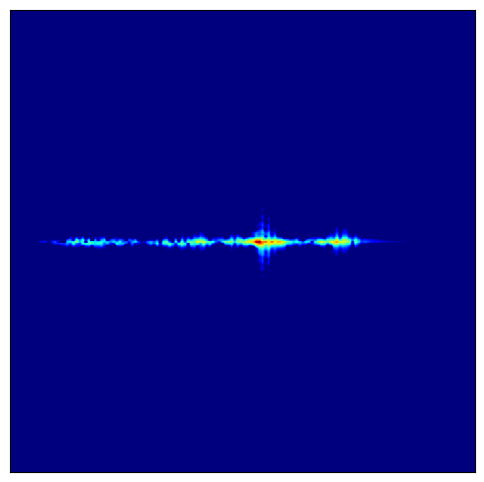

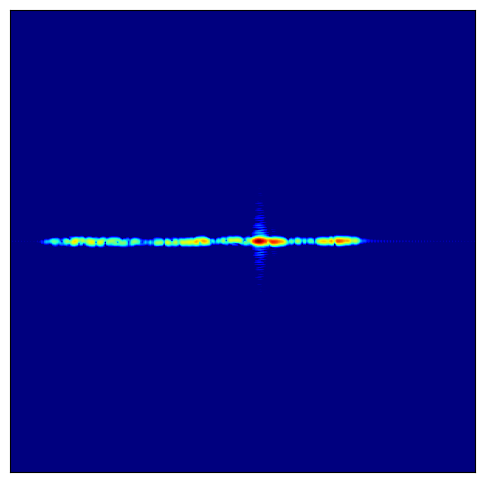

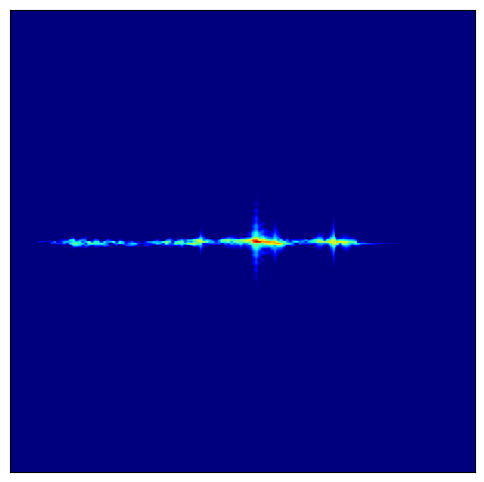

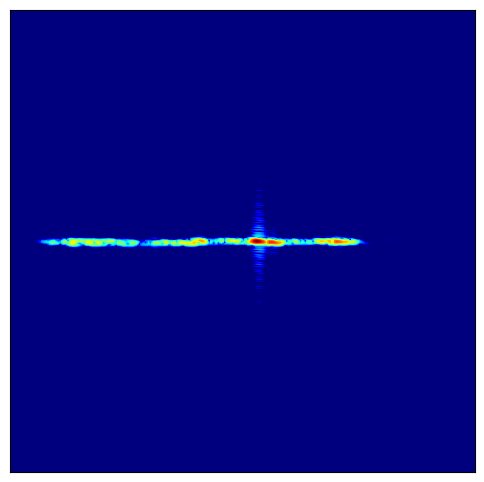

第3/200帧图像计算
转动方位起点15.225707686754326
转动方位终点15.341066445102648
转动方位总角度0.11535875834832154
转动俯仰起点87.09560600547441
转动俯仰终点87.07416416404068
转动俯仰总角度0.021441841433727404
网格数10602
RCS计算完毕
数据已保存为mat
最优: vel=-0.2214, acc=0.1189, entropy=3.2133


<Figure size 640x480 with 0 Axes>

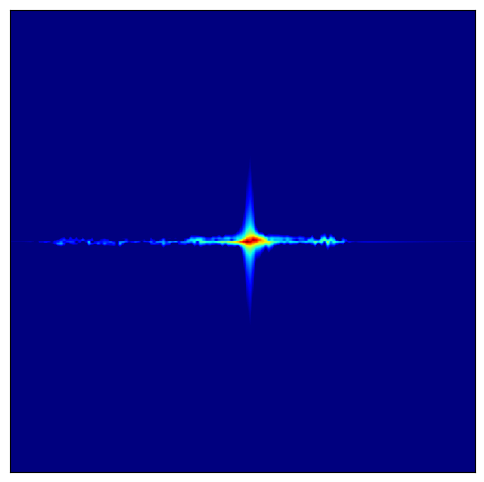

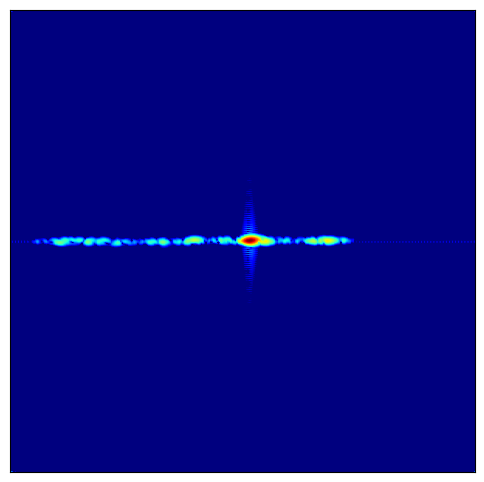

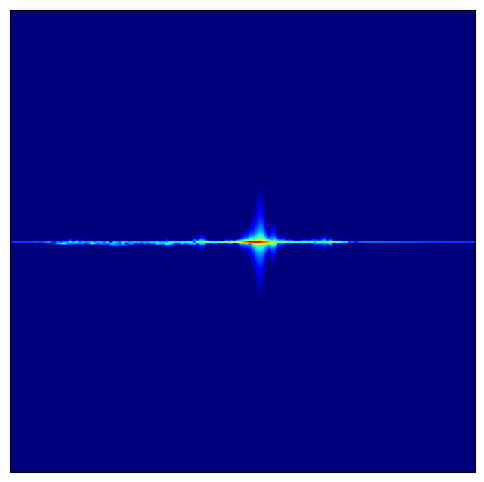

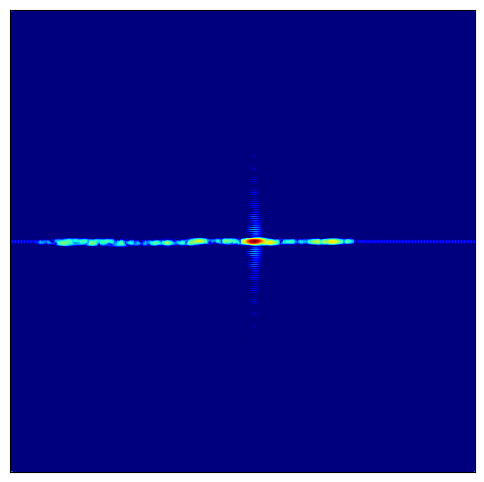

第5/200帧图像计算
转动方位起点15.458143670834817
转动方位终点15.57697705149178
转动方位总角度0.11883338065696236
转动俯仰起点87.05241585391276
转动俯仰终点87.03035475257771
转动俯仰总角度0.0220611013350549
网格数10602
RCS计算完毕
数据已保存为mat
最优: vel=0.2078, acc=0.1074, entropy=3.3305


<Figure size 640x480 with 0 Axes>

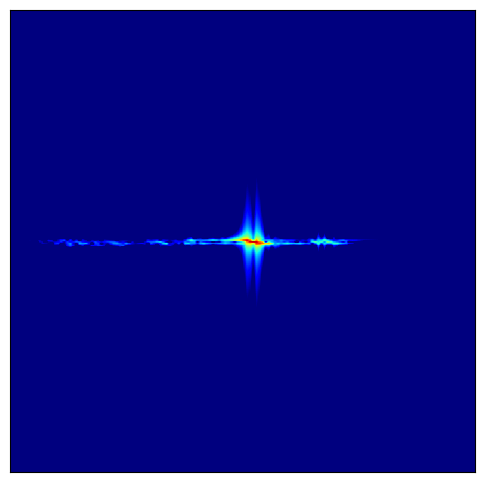

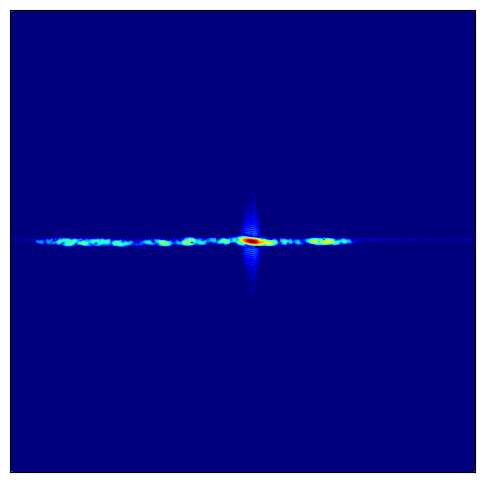

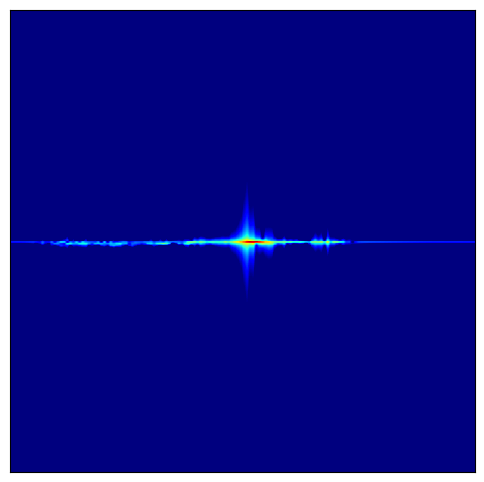

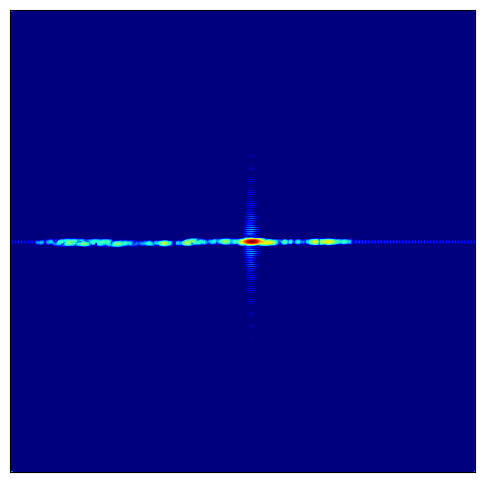

第7/200帧图像计算
转动方位起点15.697605353318627
转动方位终点15.820068458883538
转动方位总角度0.12246310556491125
转动俯仰起点87.00797437200315
转动俯仰终点86.98526805358932
转动俯仰总角度0.022706318413824533
网格数10602
RCS计算完毕
数据已保存为mat
最优: vel=-0.0627, acc=0.0115, entropy=3.1454


<Figure size 640x480 with 0 Axes>

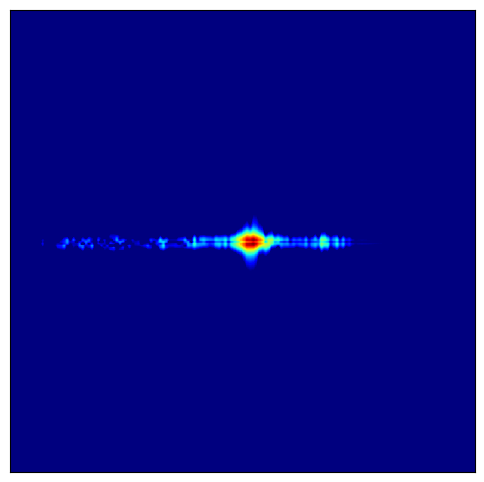

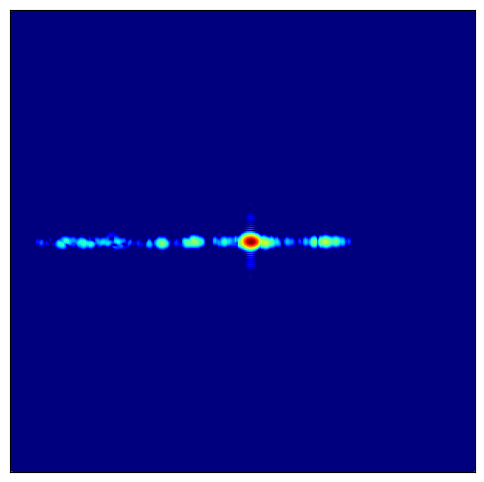

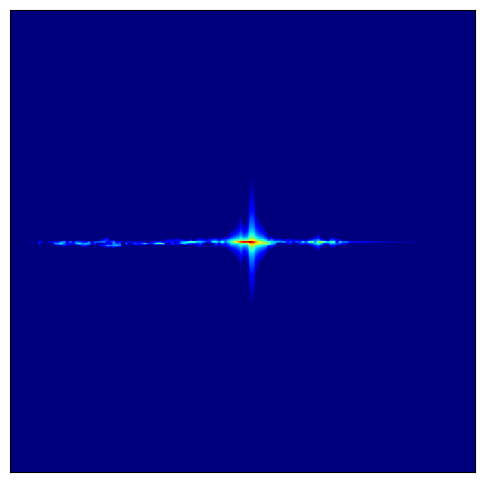

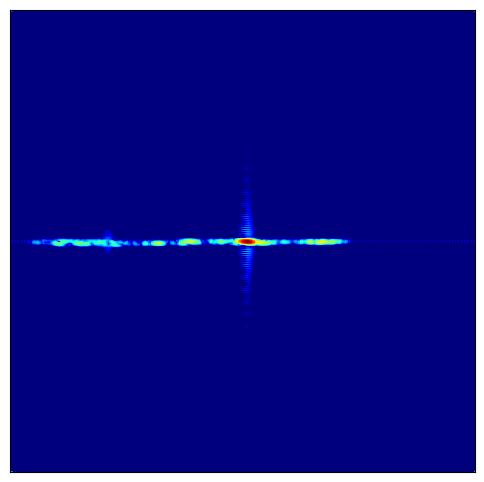

第9/200帧图像计算
转动方位起点15.944407406221044
转动方位终点16.070664429568914
转动方位总角度0.12625702334787015
转动俯仰起点86.9622289629567
转动俯仰终点86.93885008456445
转动俯仰总角度0.023378878392250613
网格数10602
RCS计算完毕
数据已保存为mat
最优: vel=-0.2149, acc=-0.0096, entropy=3.2774


<Figure size 640x480 with 0 Axes>

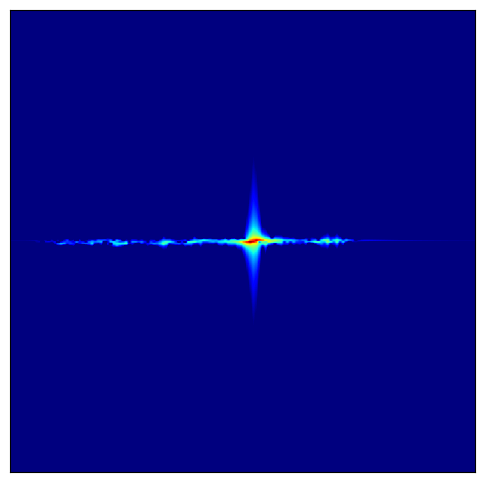

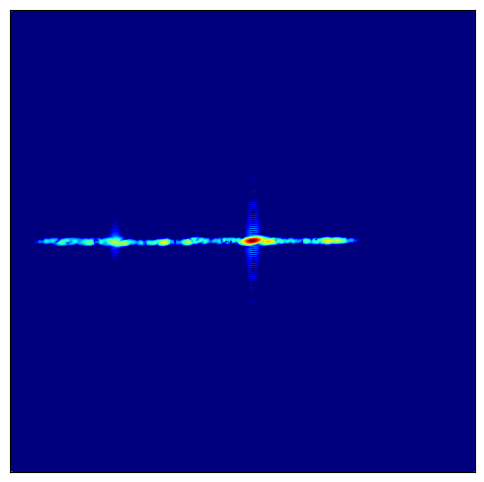

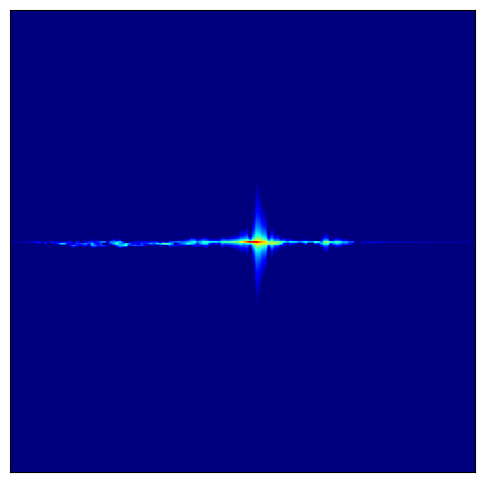

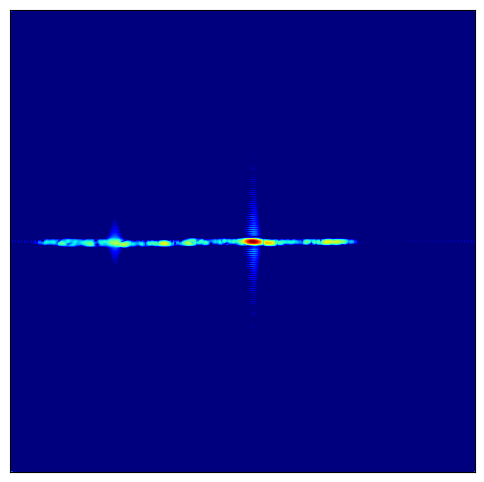

第11/200帧图像计算
转动方位起点16.198883001770902
转动方位终点16.32910787842104
转动方位总角度0.13022487665013927
转动俯仰起点86.91512421615465
转动俯仰终点86.8910439630174
转动俯仰总角度0.02408025313725659
网格数10602
RCS计算完毕
数据已保存为mat
最优: vel=-0.3743, acc=0.2201, entropy=3.3300


<Figure size 640x480 with 0 Axes>

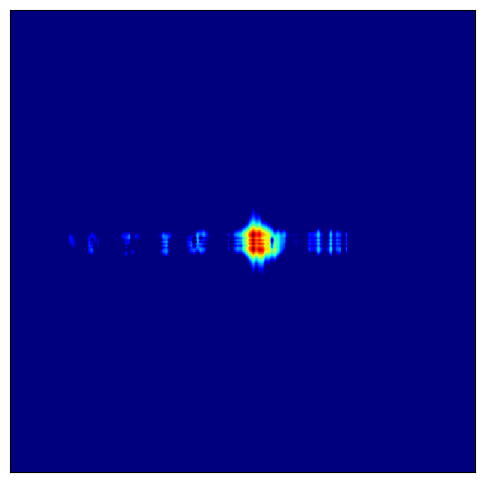

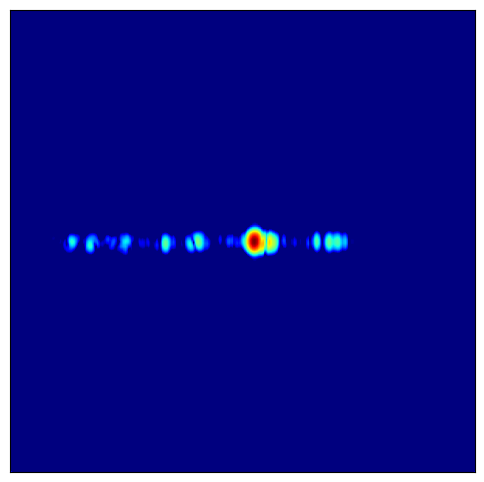

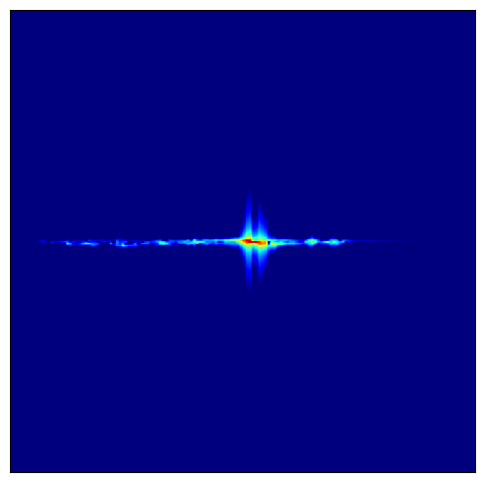

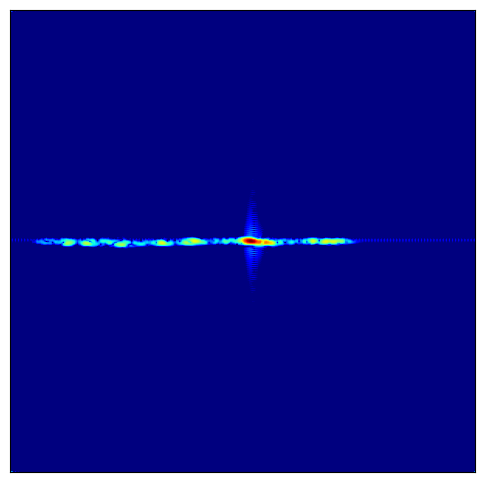

第13/200帧图像计算
转动方位起点16.461385143829926
转动方位终点16.59576225889483
转动方位总角度0.13437711506490402
转动俯仰起点86.86660173207189
转动俯仰终点86.8417897257587
转动俯仰总角度0.024812006313183588
网格数10602
RCS计算完毕
数据已保存为mat
最优: vel=-0.2607, acc=0.0355, entropy=3.3564


<Figure size 640x480 with 0 Axes>

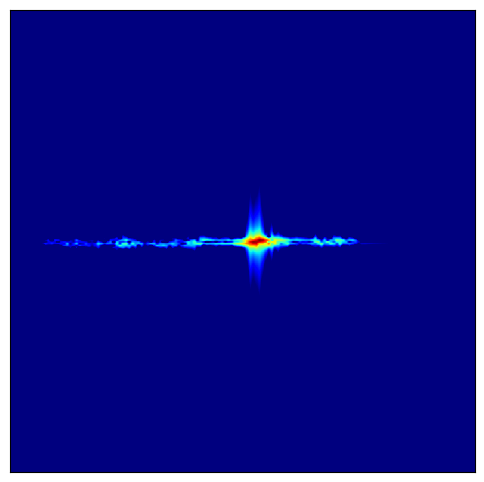

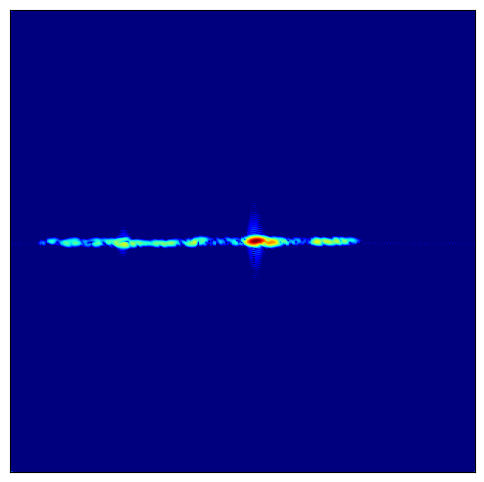

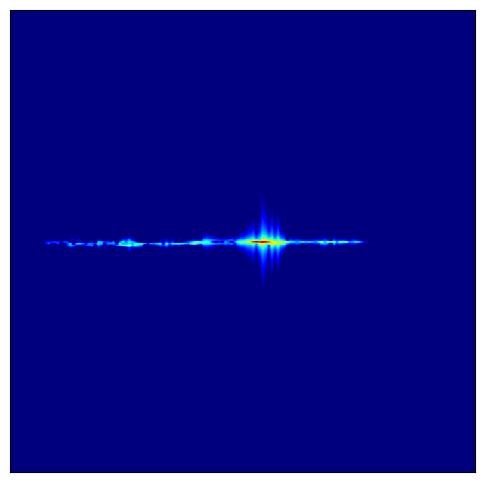

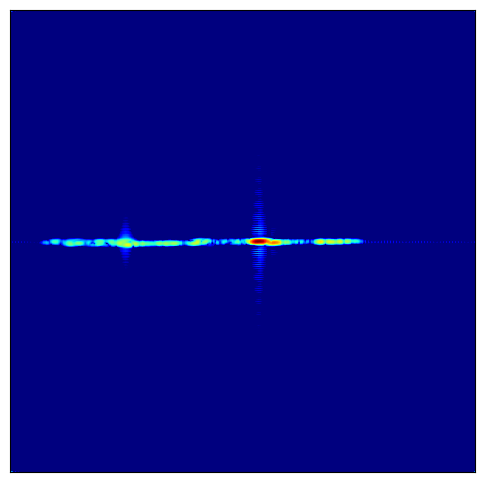

第15/200帧图像计算
转动方位起点16.73228811096324
转动方位终点16.87101306577998
转动方位总角度0.13872495481674108
转动俯仰起点86.81659993573787
转动俯仰终点86.79102413638884
转动俯仰总角度0.02557579934902776
网格数10602
RCS计算完毕
数据已保存为mat
最优: vel=-0.4481, acc=0.1106, entropy=3.3412


<Figure size 640x480 with 0 Axes>

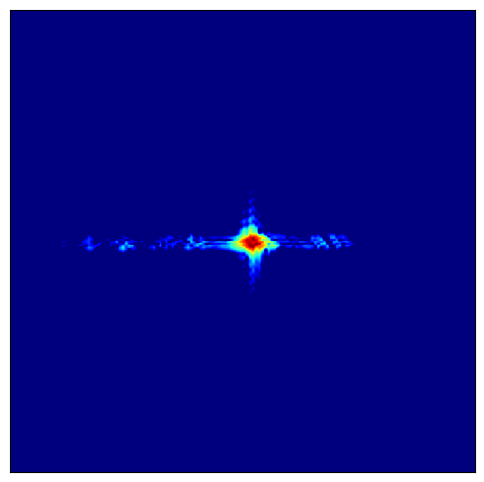

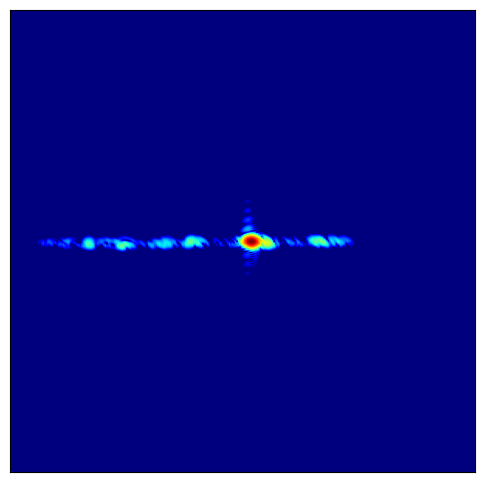

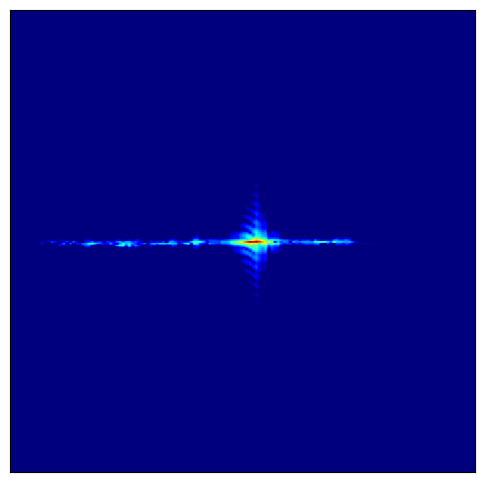

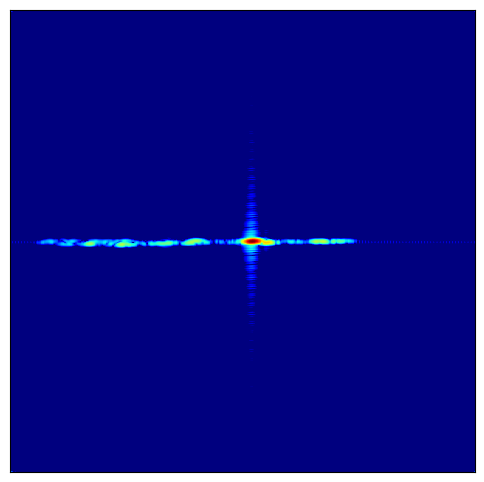

第17/200帧图像计算
转动方位起点17.011989021614923
转动方位终点17.155269465672028
转动方位总角度0.14328044405710472
转动俯仰起点86.7650538781064
转动俯仰终点86.73868048038914
转动俯仰总角度0.02637339771726488
网格数10602
RCS计算完毕
数据已保存为mat
最优: vel=-0.3287, acc=0.0842, entropy=3.2896


<Figure size 640x480 with 0 Axes>

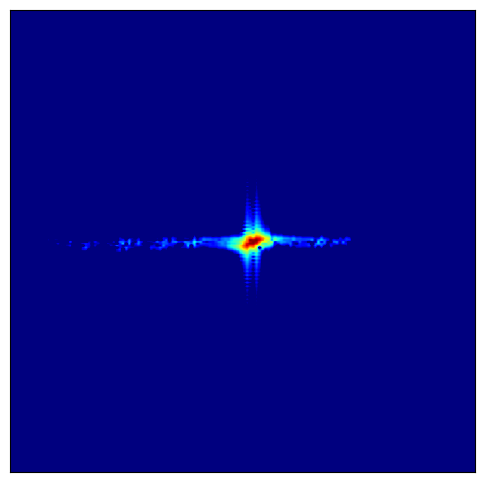

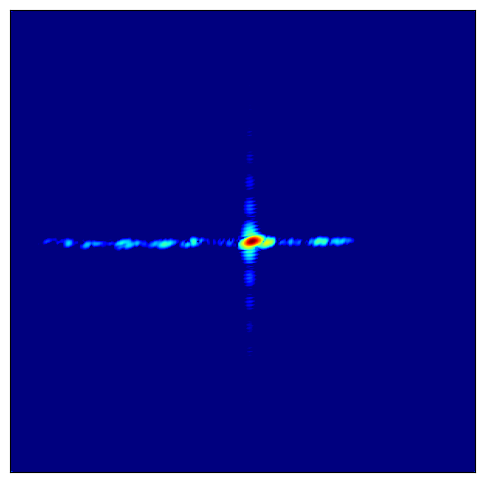

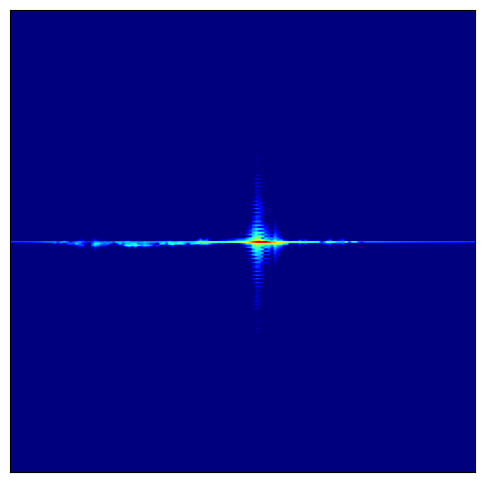

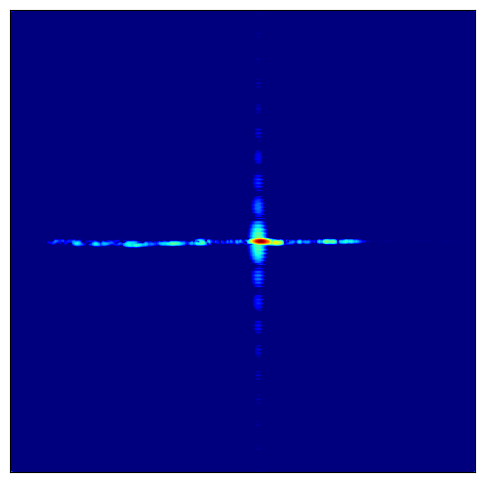

第19/200帧图像计算
转动方位起点17.300909532885697
转动方位终点17.448966067214982
转动方位总角度0.14805653432928523
转动俯仰起点86.71189502471499
转动俯仰终点86.68468834720046
转动俯仰总角度0.027206677514527655
网格数10602
RCS计算完毕
数据已保存为mat
最优: vel=1.1190, acc=-1.1476, entropy=3.4449


<Figure size 640x480 with 0 Axes>

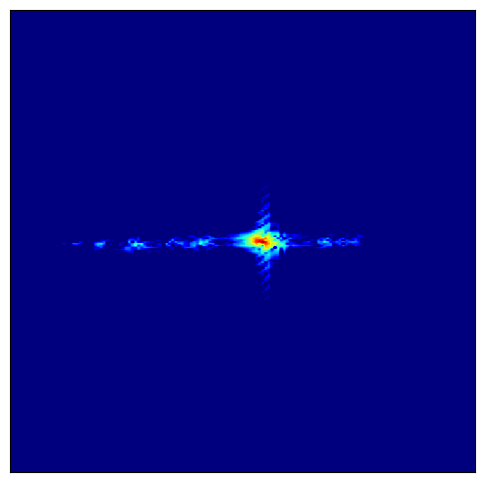

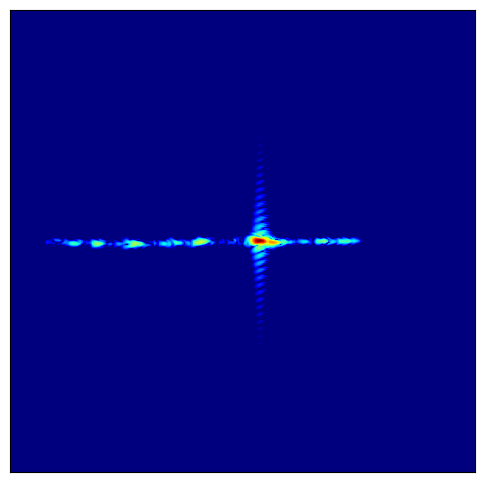

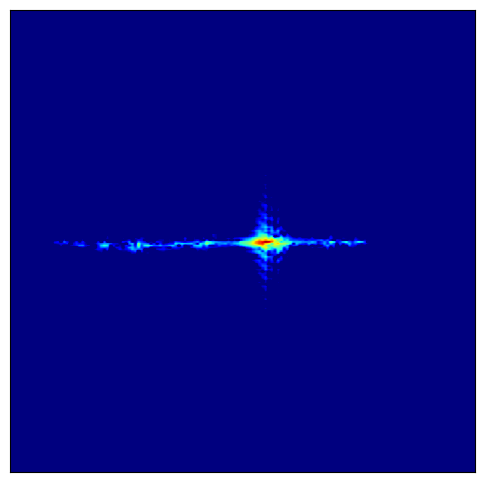

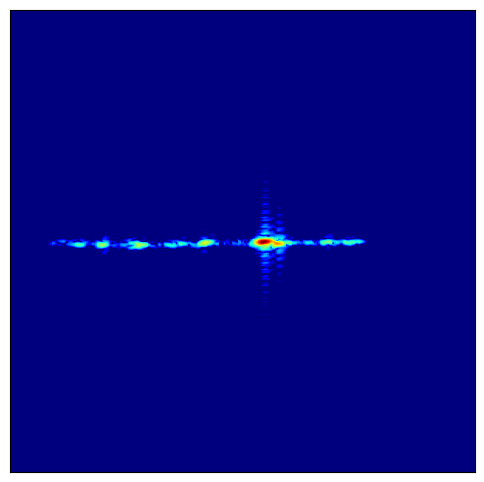

第21/200帧图像计算
转动方位起点17.599497685552315
转动方位终点17.752564844368543
转动方位总角度0.1530671588162278
转动俯仰起点86.6570510310389
转动俯仰终点86.6289733987145
转动俯仰总角度0.028077632324396973
网格数10602
RCS计算完毕
数据已保存为mat
最优: vel=-0.5995, acc=0.3577, entropy=3.5086


<Figure size 640x480 with 0 Axes>

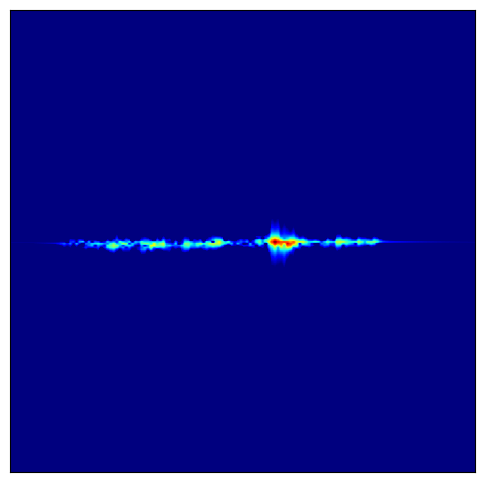

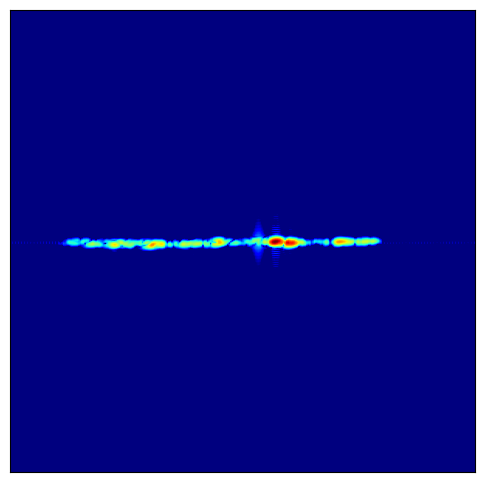

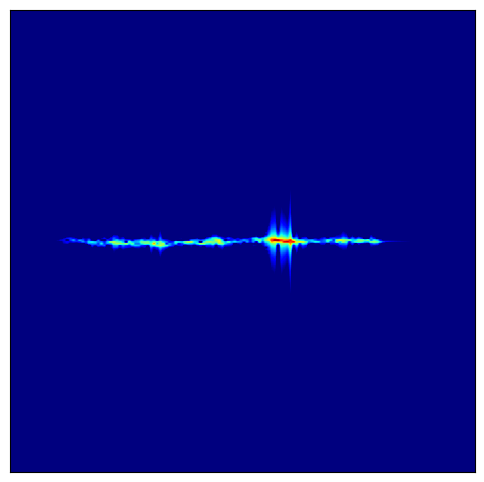

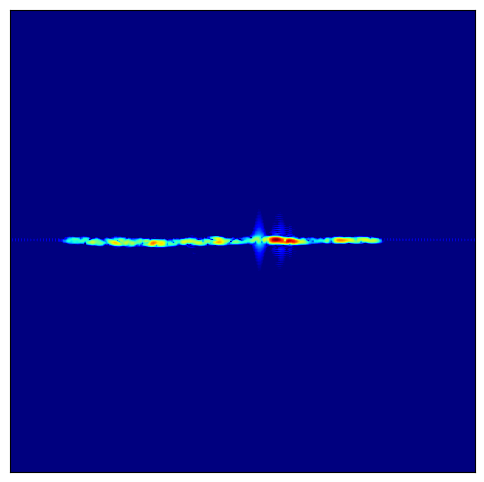

第23/200帧图像计算
转动方位起点17.90822990922174
转动方位终点18.066557227263687
转动方位总角度0.15832731804194822
转动俯仰起点86.60044550398895
转动俯仰终点86.57145712365731
转动俯仰总角度0.028988380331639974
网格数10602
RCS计算完毕
数据已保存为mat
最优: vel=0.0398, acc=0.0495, entropy=3.5267


<Figure size 640x480 with 0 Axes>

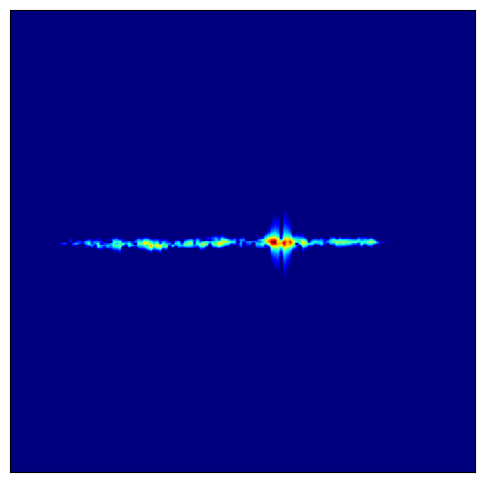

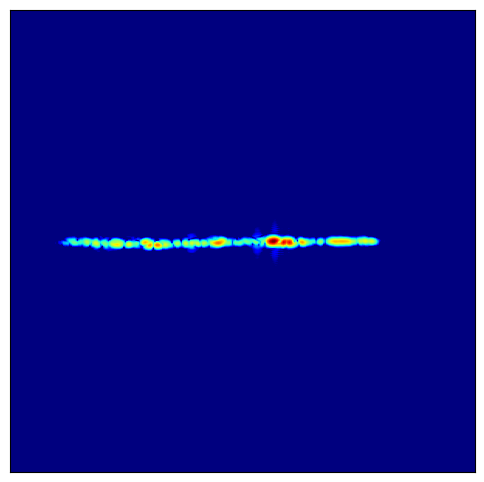

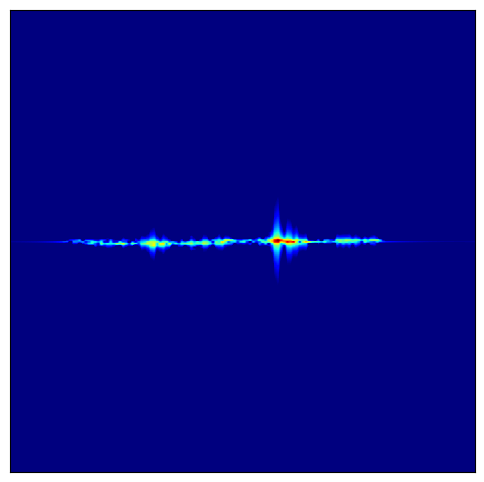

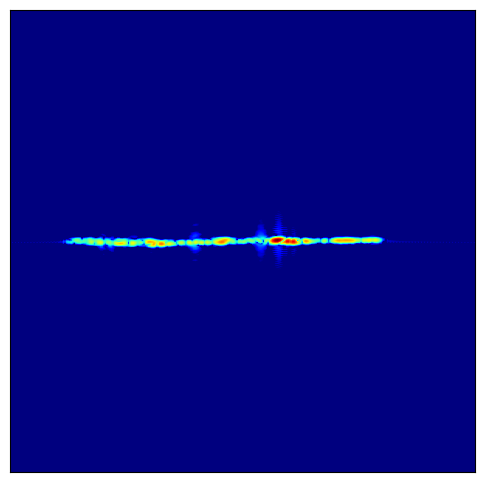

第25/200帧图像计算
转动方位起点18.227613202884488
转动方位终点18.391466376641276
转动方位总角度0.1638531737567881
转动俯仰起点86.54199774907168
转动俯仰终点86.51205657743031
转动俯仰总角度0.02994117164136867
网格数10602
RCS计算完毕
数据已保存为mat
最优: vel=-0.4257, acc=0.5612, entropy=3.5306


<Figure size 640x480 with 0 Axes>

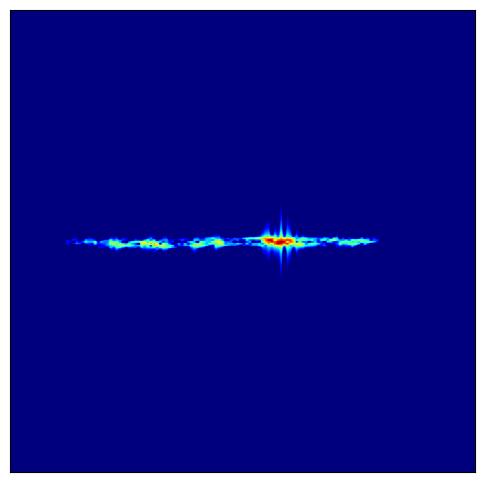

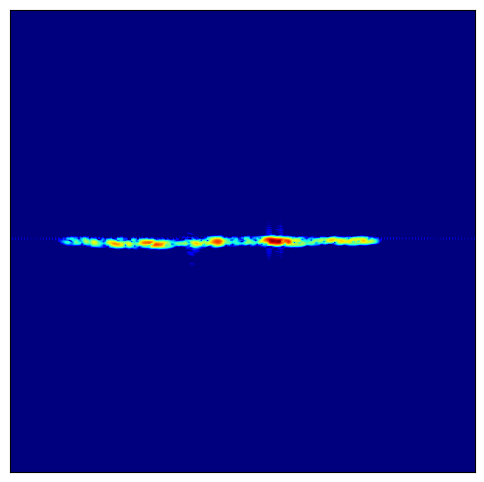

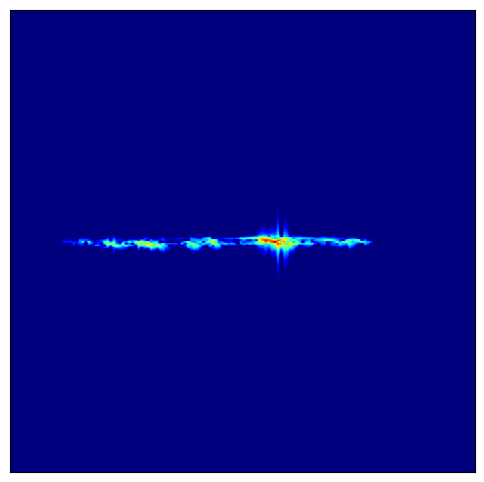

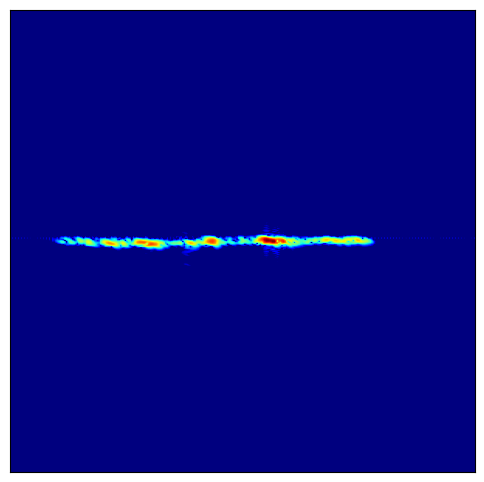

第27/200帧图像计算
转动方位起点18.55818750762543
转动方位终点18.727849659428518
转动方位总角度0.16966215180308808
转动俯仰起点86.48162250283181
转动俯仰终点86.45068410709429
转动俯仰总角度0.030938395737521773
网格数10602
RCS计算完毕
数据已保存为mat
最优: vel=-0.2830, acc=0.0488, entropy=3.6081


<Figure size 640x480 with 0 Axes>

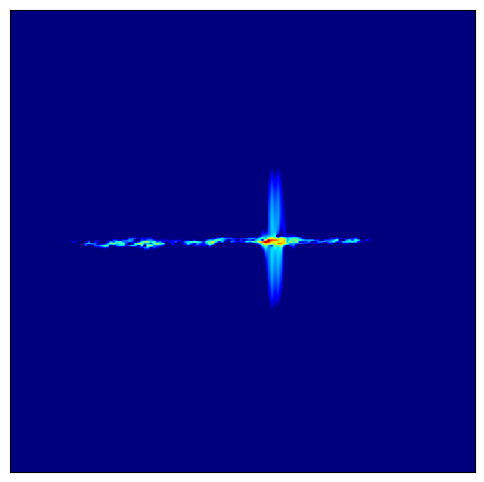

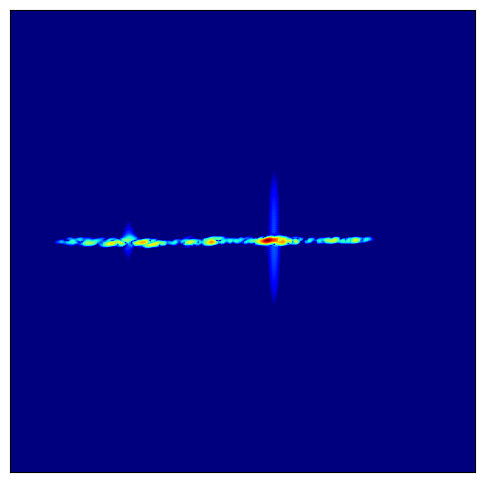

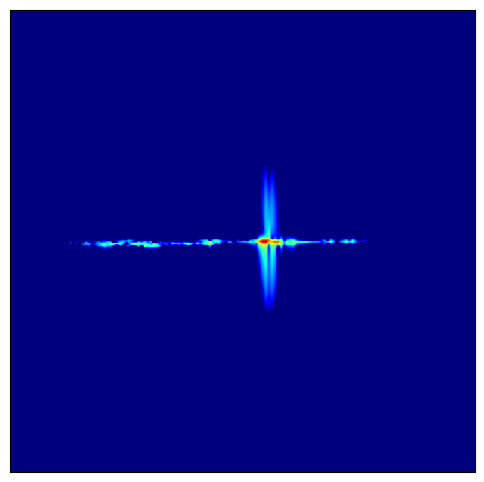

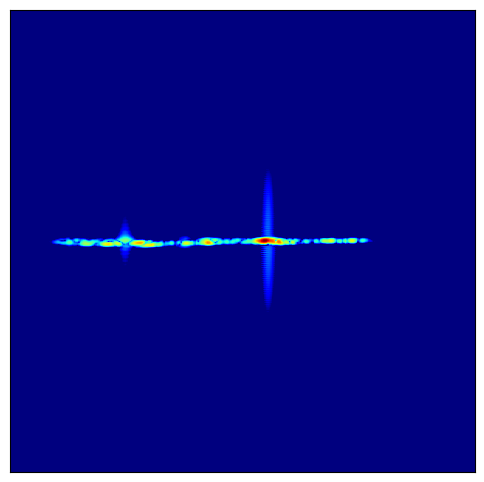

第29/200帧图像计算
转动方位起点18.900528289875023
转动方位终点19.076301344697967
转动方位总角度0.17577305482294392
转动俯仰起点86.41922965034041
转动俯仰终点86.38724706135073
转动俯仰总角度0.03198258898967765
网格数10602
RCS计算完毕
数据已保存为mat
最优: vel=0.3533, acc=0.1654, entropy=3.4131


<Figure size 640x480 with 0 Axes>

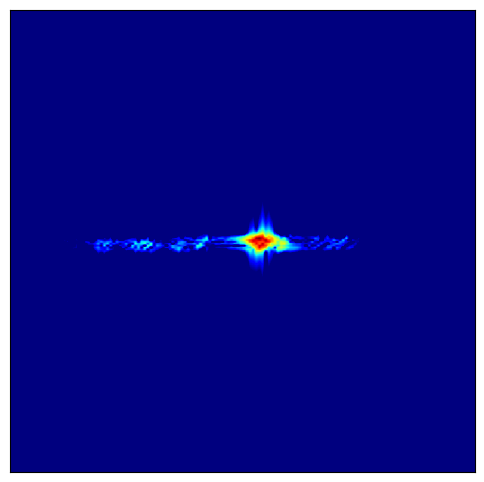

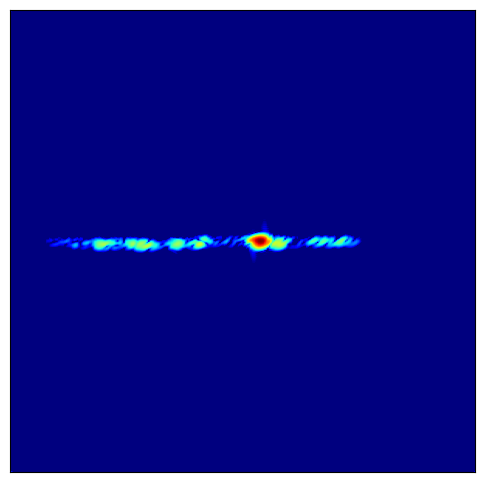

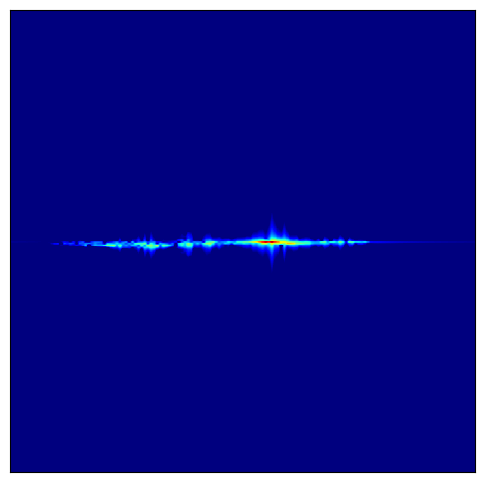

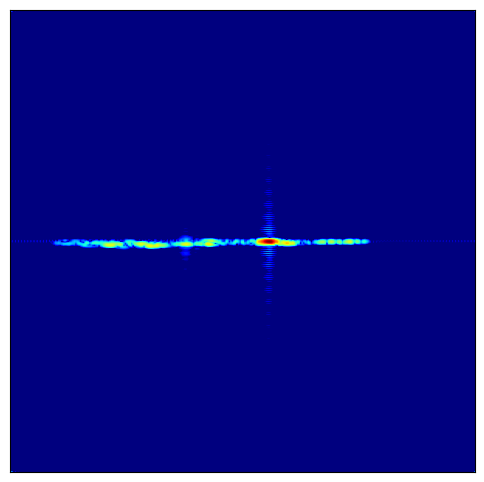

第31/200帧图像计算
转动方位起点19.255249355340876
转动方位终点19.437455541077664
转动方位总角度0.18220618573678848
转动俯仰起点86.35472392768864
转动俯仰终点86.32164748560223
转动俯仰总角度0.03307644208641136
网格数10602
RCS计算完毕
数据已保存为mat
最优: vel=-0.2405, acc=0.0700, entropy=3.3865


<Figure size 640x480 with 0 Axes>

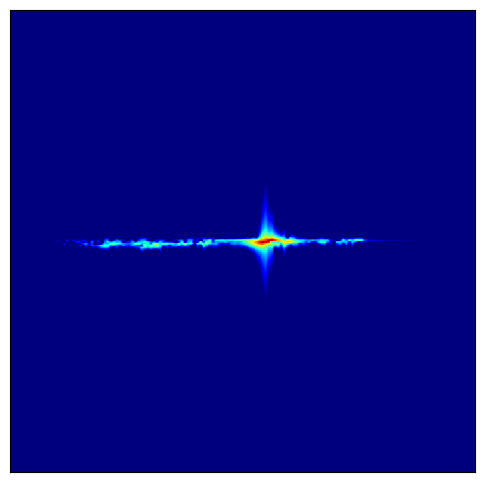

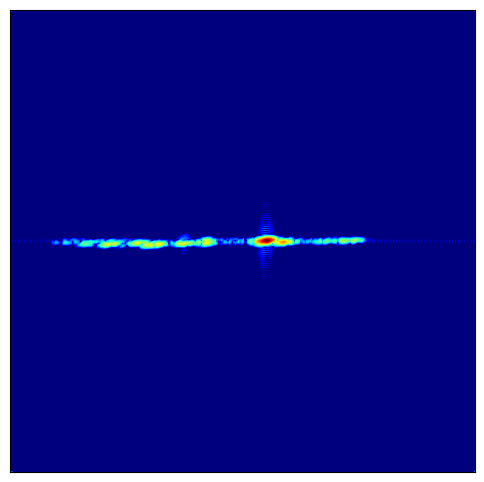

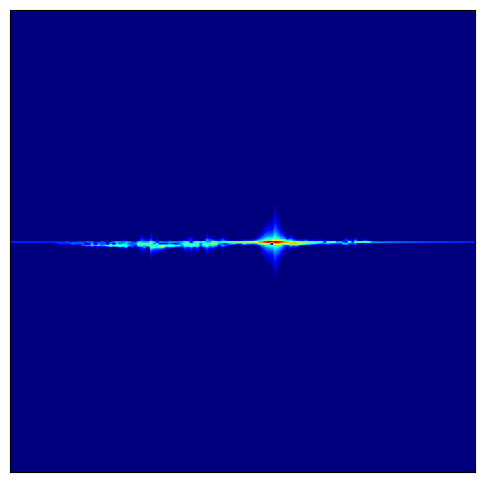

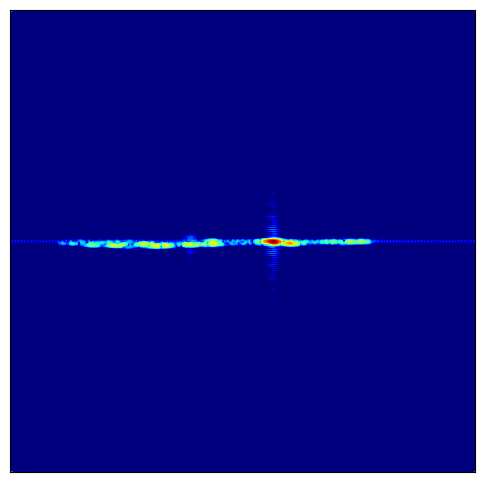

第33/200帧图像计算
转动方位起点19.62300591565107
转动方位终点19.811989398638104
转动方位总角度0.18898348298703382
转动俯仰起点86.28800460970962
转动俯仰终点86.25378180247687
转动俯仰总角度0.034222807232751506
网格数10602
RCS计算完毕
数据已保存为mat
最优: vel=-0.0684, acc=0.1917, entropy=3.4020


<Figure size 640x480 with 0 Axes>

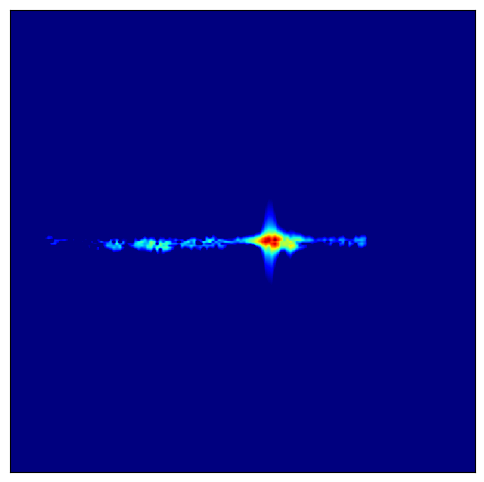

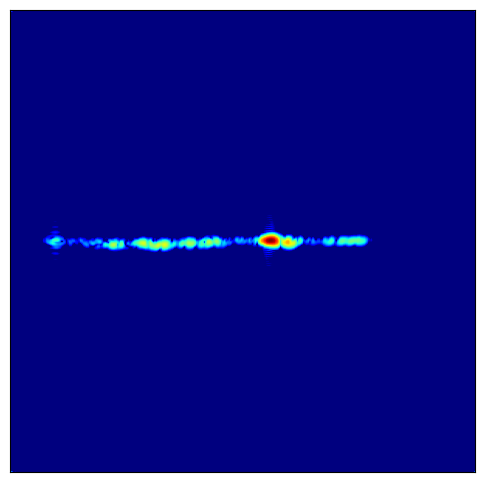

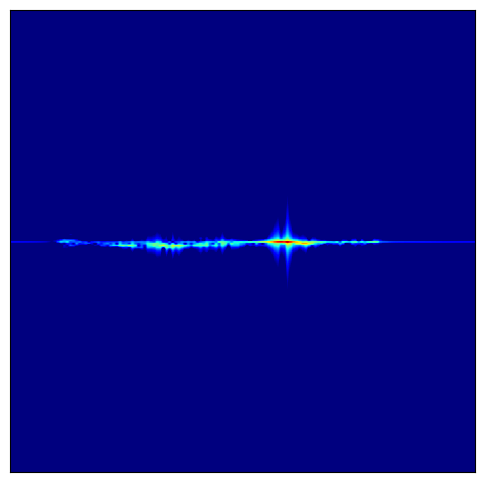

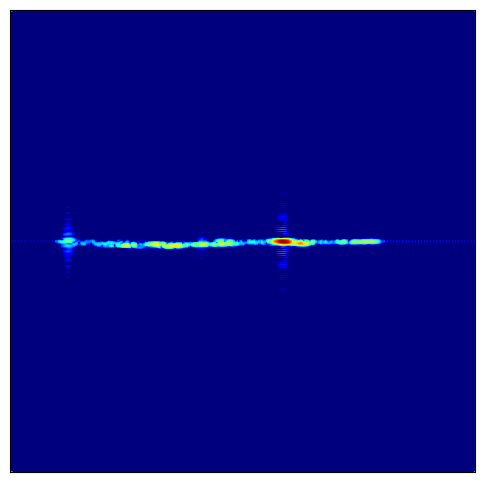

第35/200帧图像计算
转动方位起点20.004497931760113
转动方位终点20.200626600363993
转动方位总角度0.19612866860387967
转动俯仰起点86.21896518349921
转动俯仰终点86.1835404785996
转动俯仰总角度0.03542470489961147
网格数10602
RCS计算完毕
数据已保存为mat
最优: vel=-0.3942, acc=0.1114, entropy=3.4096


<Figure size 640x480 with 0 Axes>

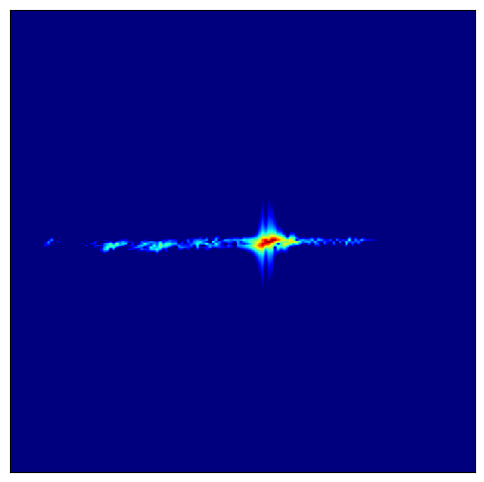

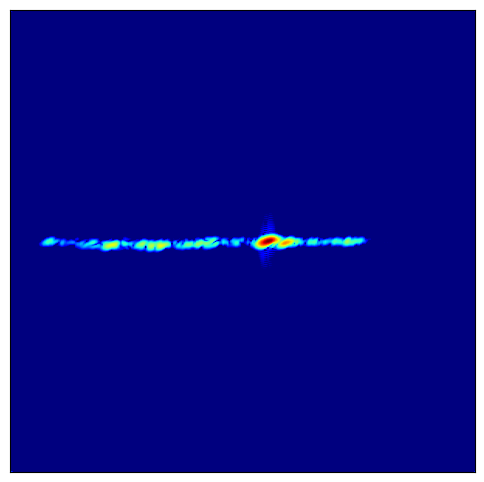

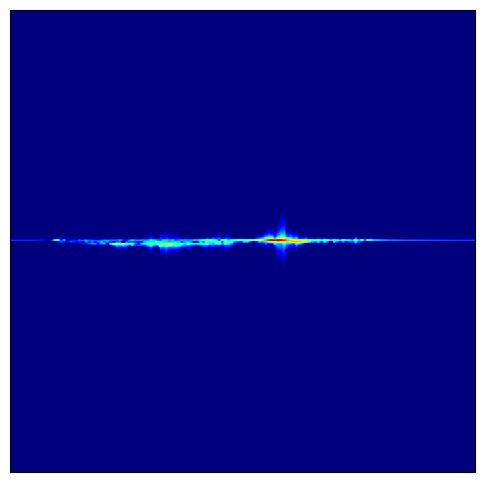

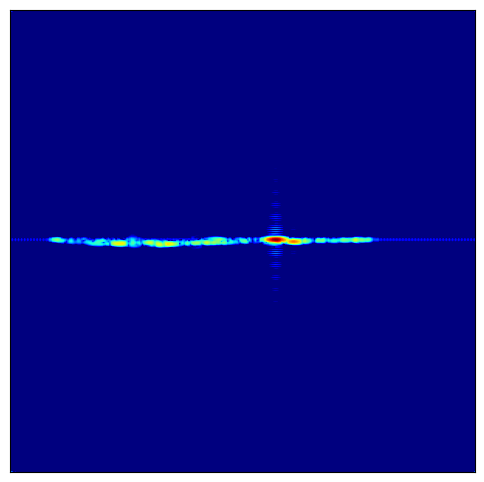

第37/200帧图像计算
转动方位起点20.400473760310053
转动方位终点20.60414117051124
转动方位总角度0.20366741020118795
转动俯仰起点86.14749300876082
转动俯仰终点86.11080767891121
转动俯仰总角度0.03668532984960393
网格数10602
RCS计算完毕
数据已保存为mat
最优: vel=-0.0473, acc=0.1109, entropy=3.5050


<Figure size 640x480 with 0 Axes>

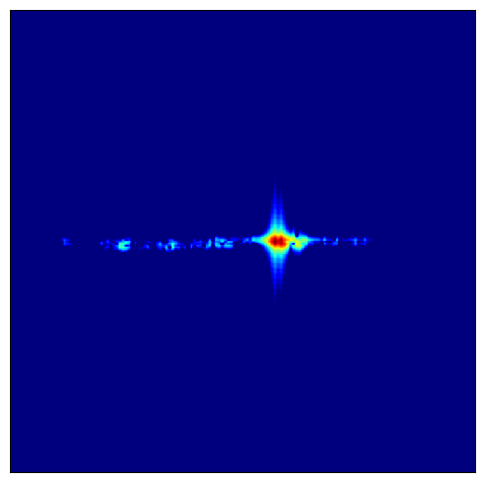

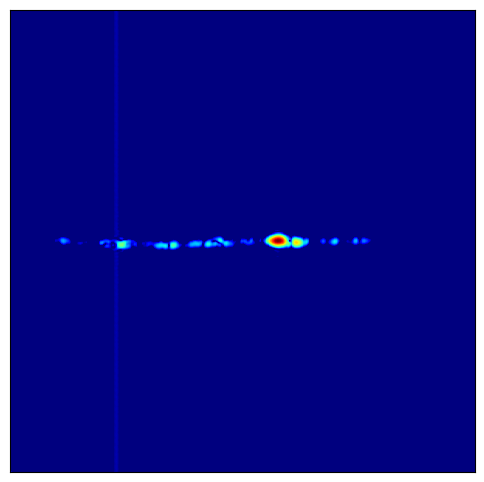

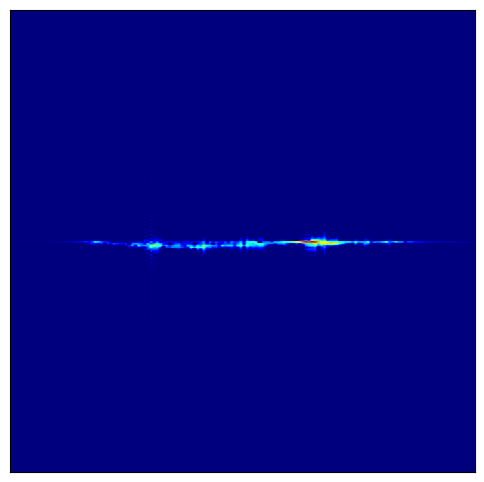

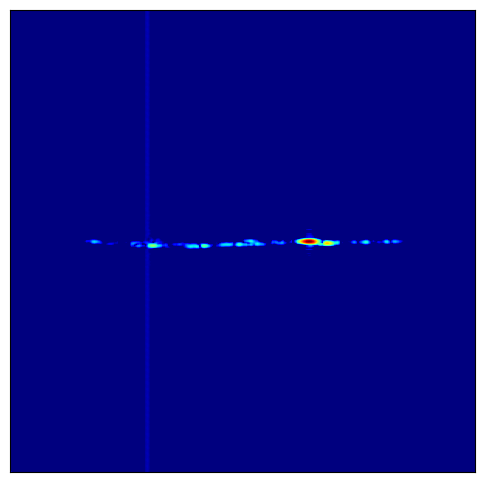

第39/200帧图像计算
转动方位起点20.81173413137783
转动方位终点21.02336162943001
转动方位总角度0.21162749805218084
转动俯仰起点86.07346896658755
转动俯仰终点86.0354609105028
转动俯仰总角度0.03800805608474889
网格数10602
RCS计算完毕
数据已保存为mat
最优: vel=0.0248, acc=-0.0411, entropy=3.2935


<Figure size 640x480 with 0 Axes>

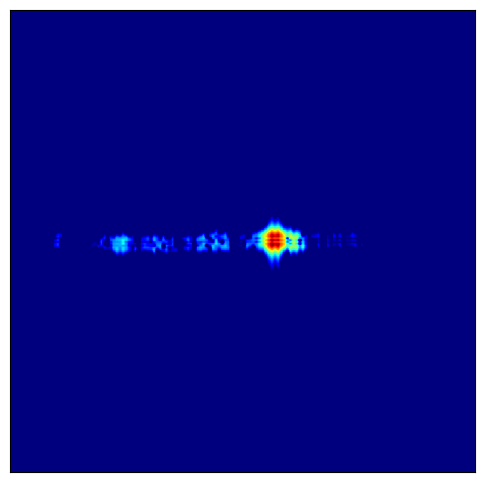

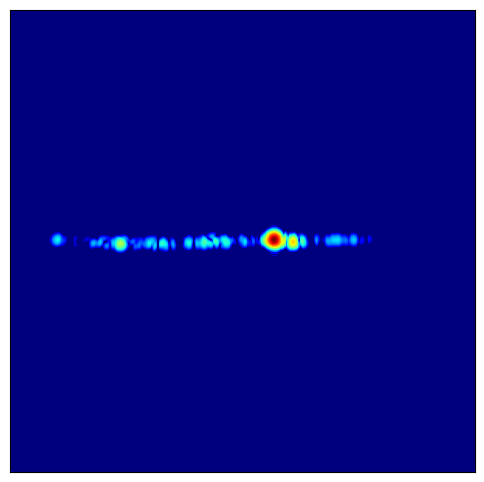

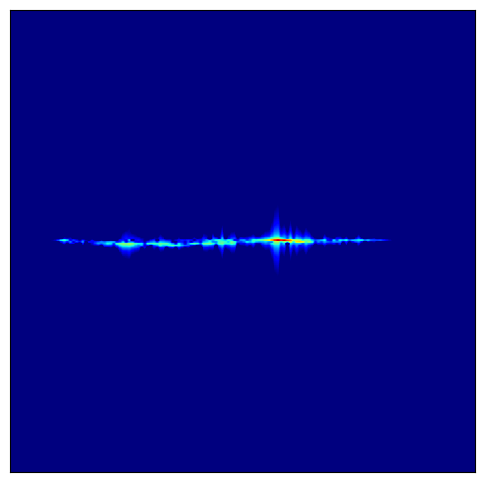

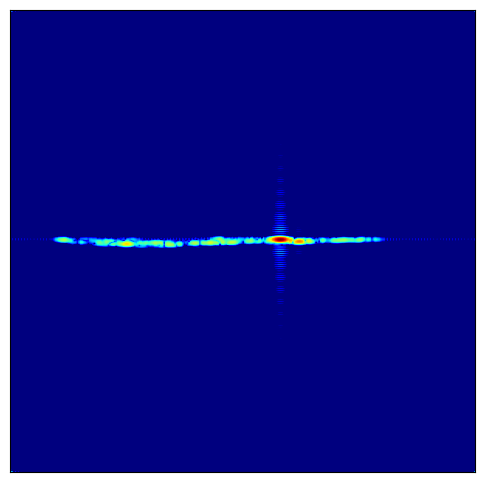

第41/200帧图像计算
转动方位起点21.239136488351285
转动方位终点21.45917552676242
转动方位总角度0.2200390384111337
转动俯仰起点85.9967670990514
转动俯仰终点85.9573706587896
转动俯仰总角度0.039396440261796783
网格数10602
RCS计算完毕
数据已保存为mat
最优: vel=-0.1812, acc=0.1080, entropy=3.3503


<Figure size 640x480 with 0 Axes>

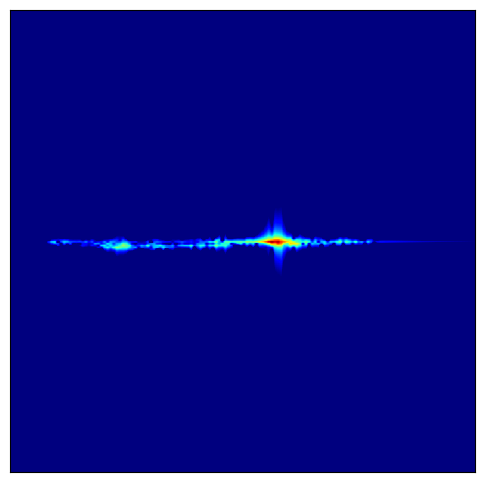

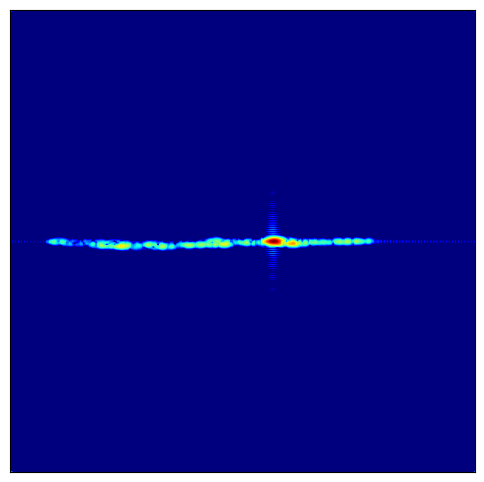

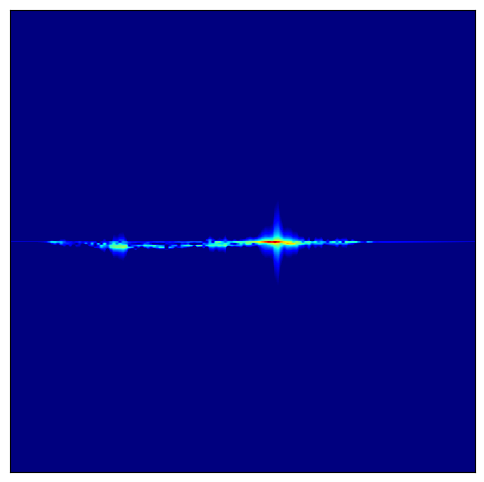

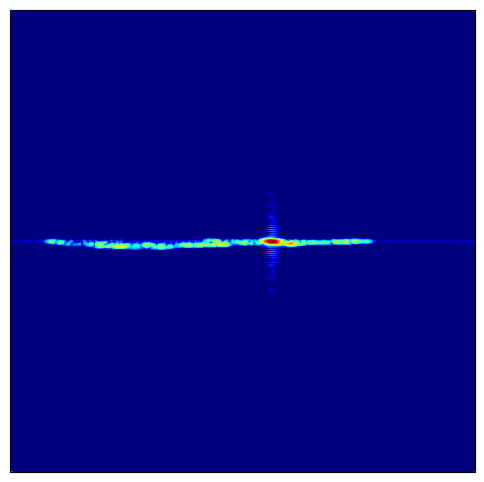

第43/200帧图像计算
转动方位起点21.68359972300627
转动方位终点21.91253438724009
转动方位总角度0.2289346642338188
转动俯仰起点85.91725424293526
转动俯仰终点85.87640001993708
转动俯仰总角度0.04085422299817765
网格数10602
RCS计算完毕
数据已保存为mat
最优: vel=-0.1759, acc=0.0613, entropy=3.5669


<Figure size 640x480 with 0 Axes>

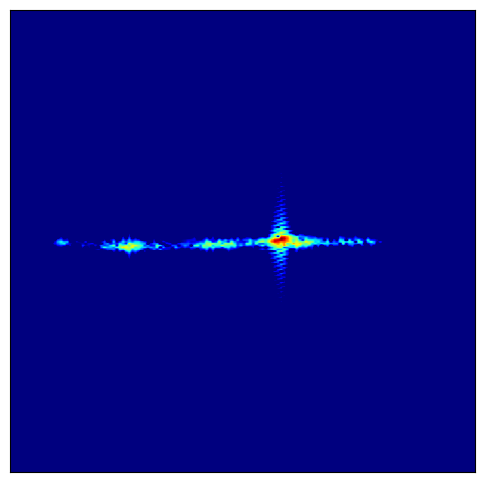

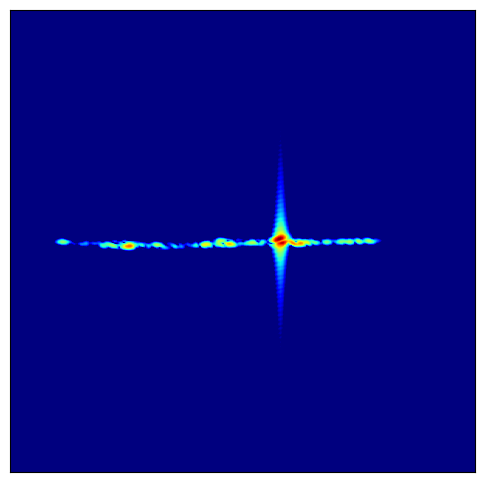

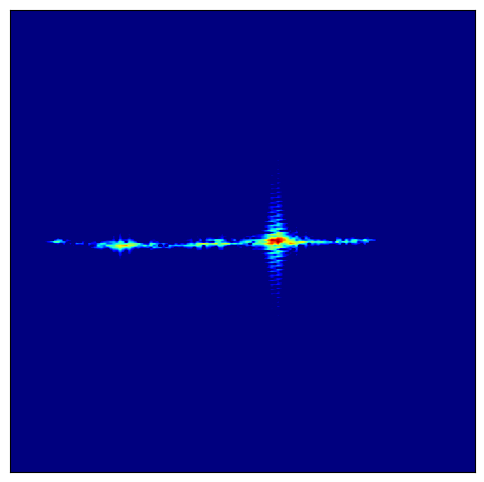

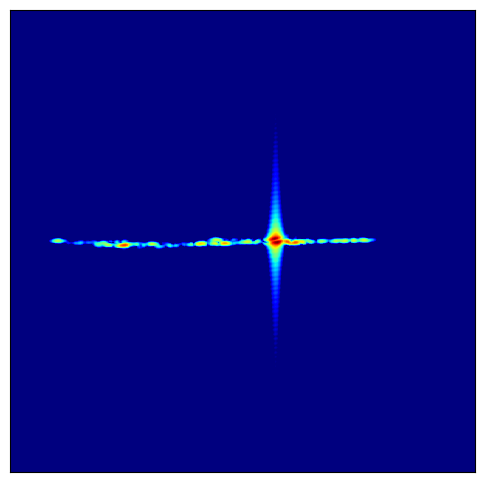

第45/200帧图像计算
转动方位起点22.146109341140345
转动方位终点22.384459105531143
转动方位总角度0.23834976439079725
转动俯仰起点85.83478966217189
转动俯仰终点85.79240433483632
转动俯仰总角度0.0423853273355661
网格数10602
RCS计算完毕
数据已保存为mat
最优: vel=0.3250, acc=-0.1927, entropy=3.5492


<Figure size 640x480 with 0 Axes>

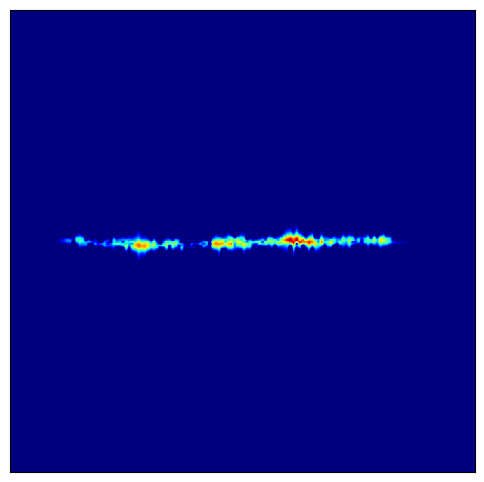

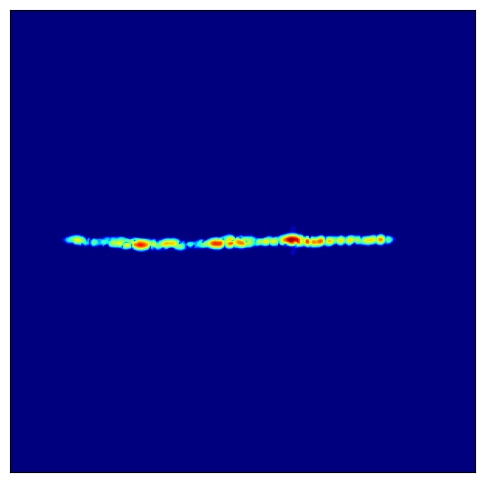

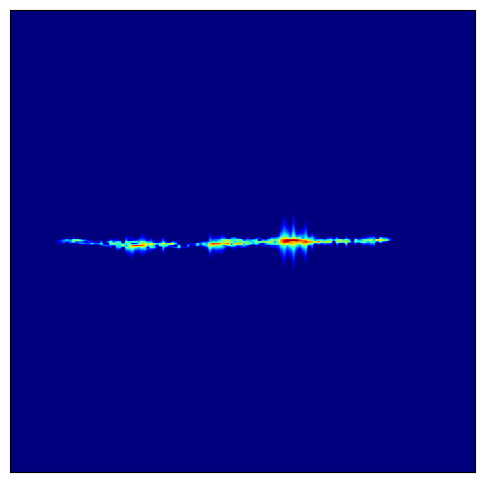

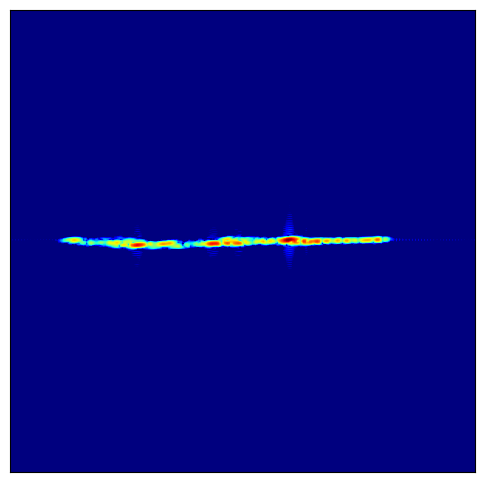

第47/200帧图像计算
转动方位起点22.627723096253426
转动方位终点22.876045828595892
转动方位总角度0.2483227323424657
转动俯仰起点85.74922468510921
转动俯仰终点85.70523083167154
转动俯仰总角度0.04399385343766937
网格数10602
RCS计算完毕
数据已保存为mat
最优: vel=-0.2242, acc=0.2932, entropy=3.5939


<Figure size 640x480 with 0 Axes>

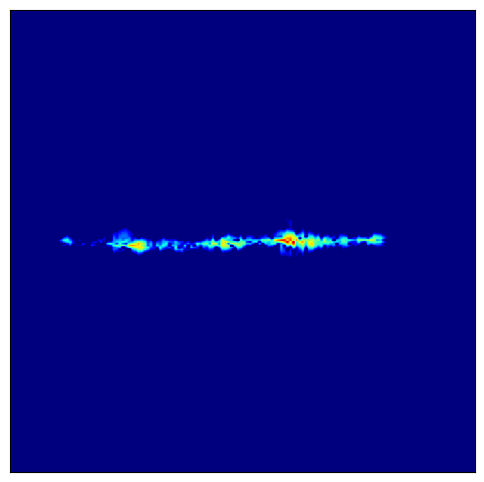

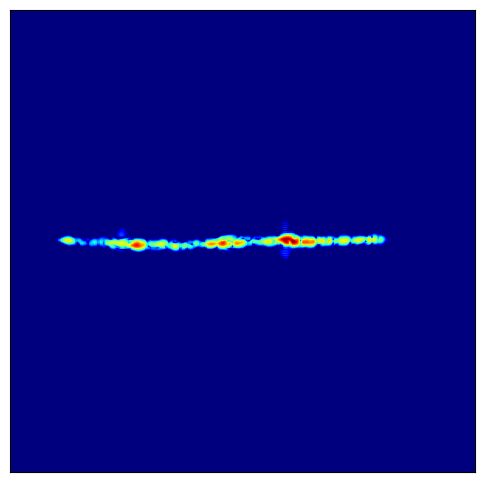

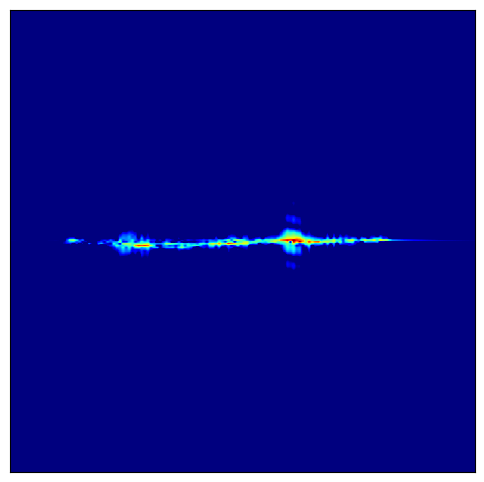

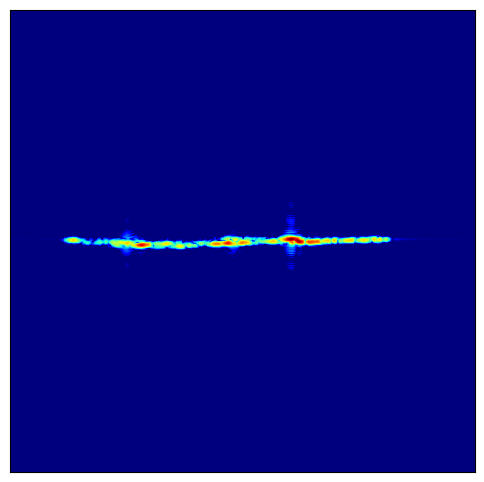

第49/200帧图像计算
转动方位起点23.12957713061175
转动方位终点23.38847236564633
转动方位总角度0.25889523503457923
转动俯仰起点85.66040235468243
转动俯仰终点85.61471828632365
转动俯仰总角度0.04568406835878136
网格数10602
RCS计算完毕
数据已保存为mat
最优: vel=0.0196, acc=-0.0321, entropy=3.5376


<Figure size 640x480 with 0 Axes>

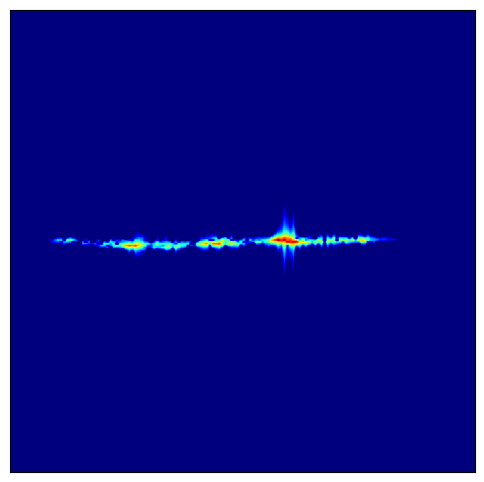

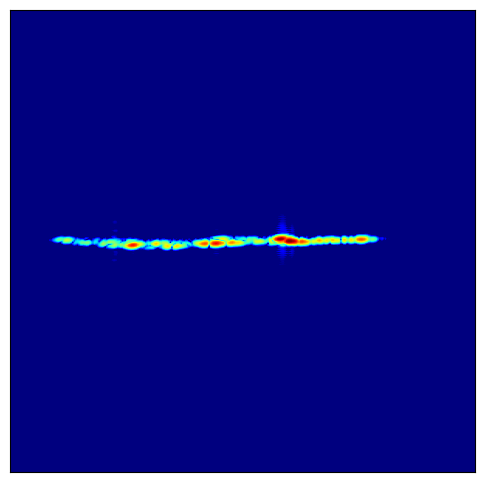

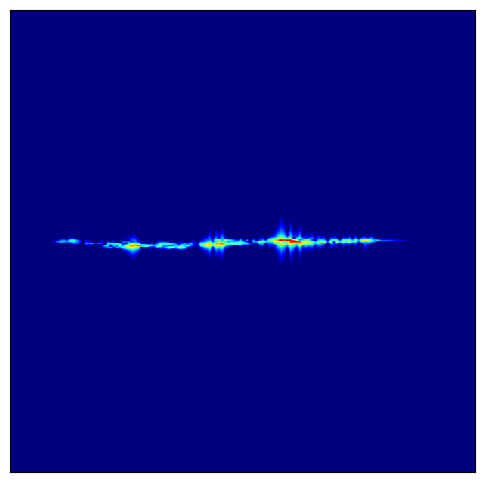

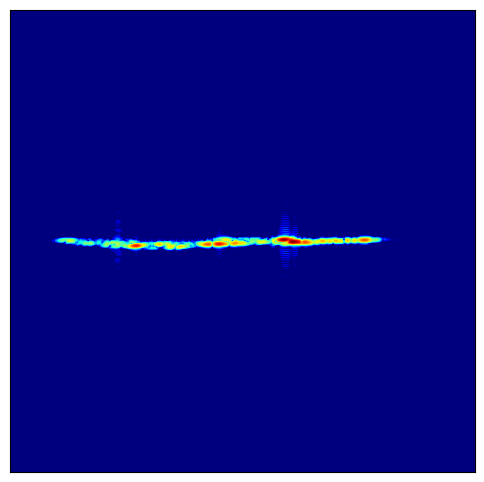

第51/200帧图像计算
转动方位起点23.652892664398742
转动方位终点23.923005166837473
转动方位总角度0.27011250243873164
转动俯仰起点85.56815710203934
转动俯仰终点85.52069671261457
转动俯仰总角度0.04746038942477071
网格数10602
RCS计算完毕
数据已保存为mat
最优: vel=-0.0039, acc=0.0500, entropy=3.5019


<Figure size 640x480 with 0 Axes>

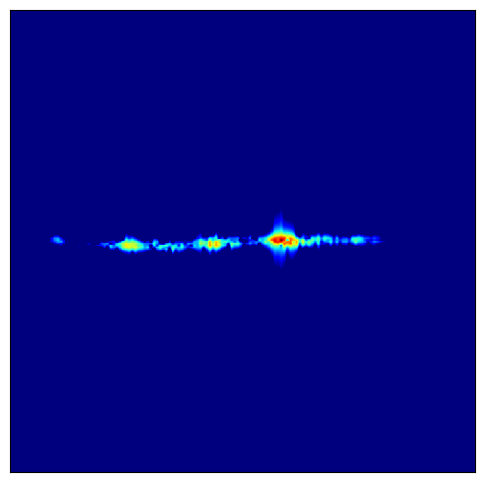

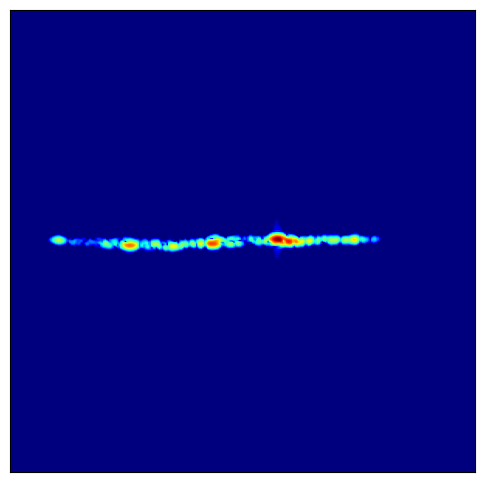

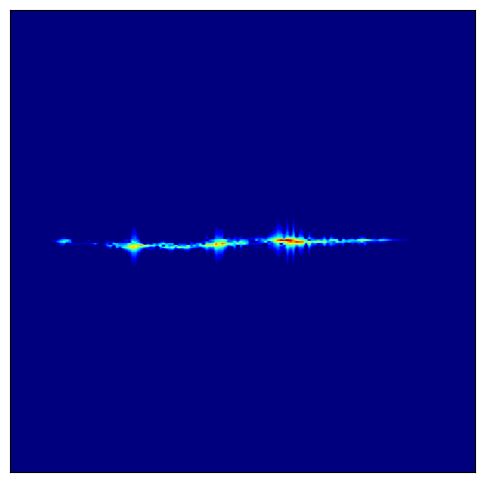

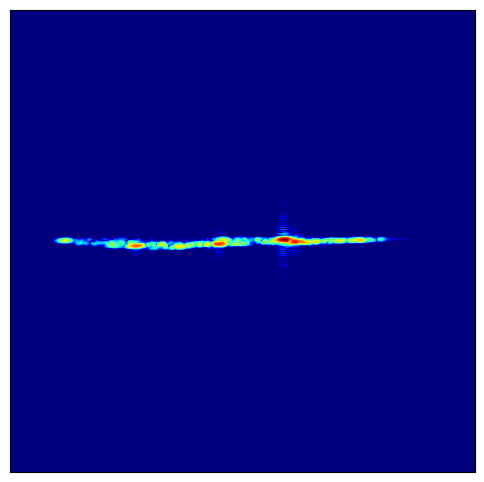

第53/200帧图像计算
转动方位起点24.198983274281435
转动方位终点24.481006911947894
转动方位总角度0.2820236376664589
转动俯仰起点85.47231445725535
转动俯仰终点85.4229870978525
转动俯仰总角度0.04932735940285227
网格数10602
RCS计算完毕
数据已保存为mat
最优: vel=0.5009, acc=-0.2377, entropy=3.5176


<Figure size 640x480 with 0 Axes>

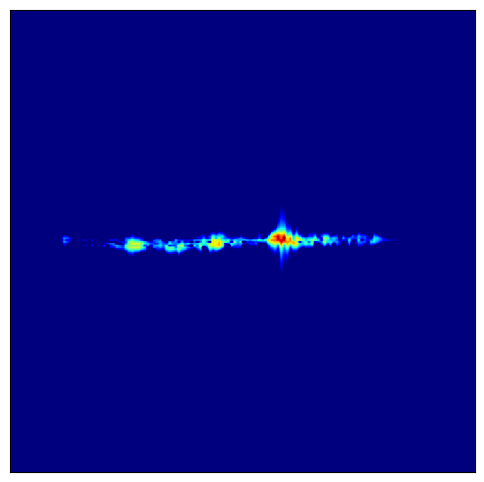

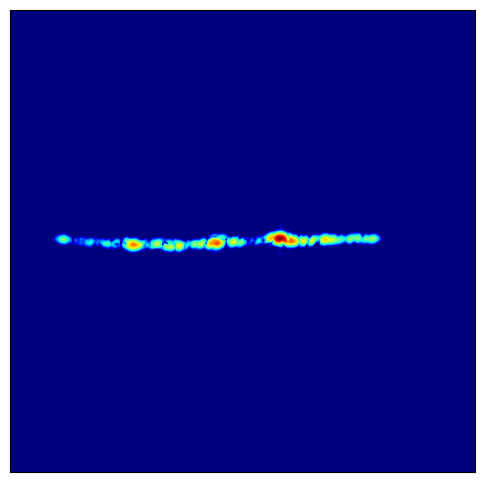

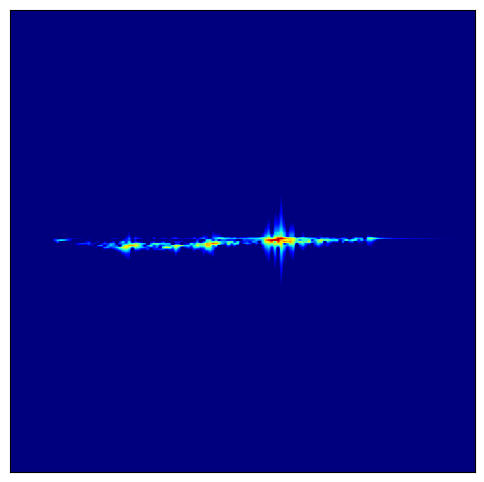

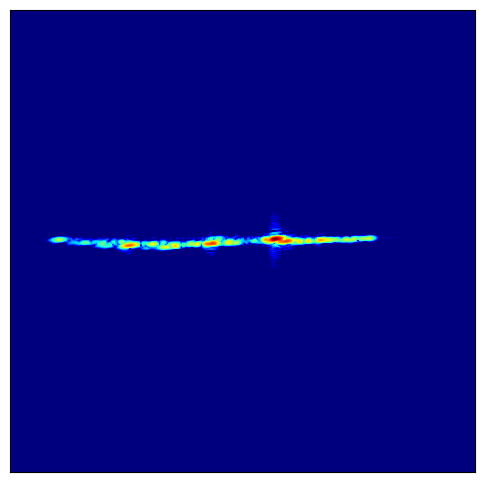

第55/200帧图像计算
转动方位起点24.76926280225215
转动方位终点25.06394474912315
转动方位总角度0.29468194687099825
转动俯仰起点85.37269081463585
转动俯仰终点85.32140120345028
转动俯仰总角度0.05128961118556674
网格数10602
RCS计算完毕
数据已保存为mat
最优: vel=8.1932, acc=-7.5466, entropy=3.8391


<Figure size 640x480 with 0 Axes>

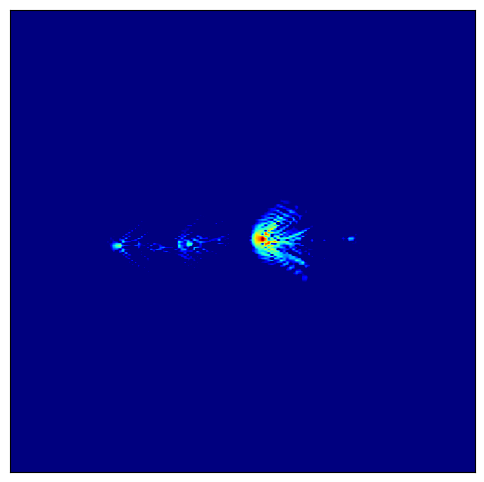

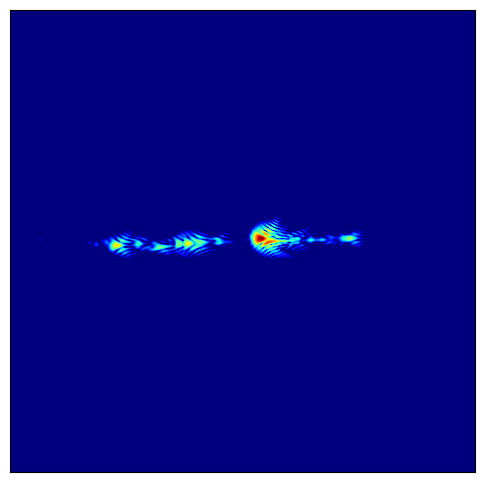

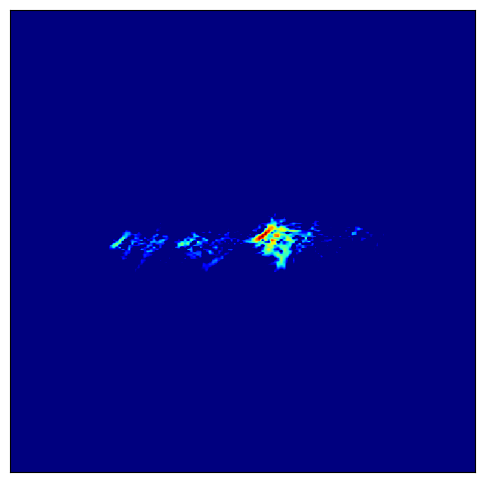

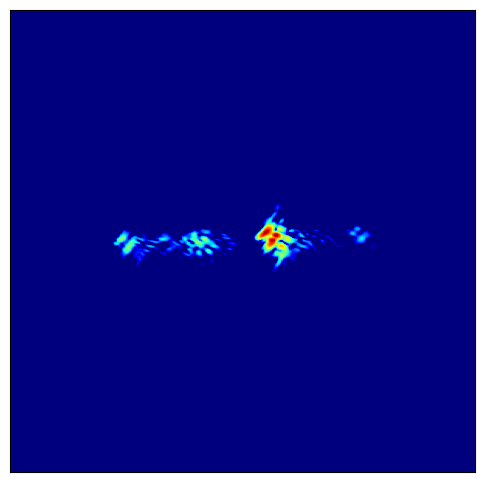

第57/200帧图像计算
转动方位起点25.36525393357205
转动方位终点25.673399220716284
转动方位总角度0.30814528714423517
转动俯仰起点85.26909327491403
转动俯仰终点85.21574145575147
转动俯仰总角度0.05335181916255749
网格数10602
RCS计算完毕
数据已保存为mat
最优: vel=0.7837, acc=-0.4589, entropy=3.6155


<Figure size 640x480 with 0 Axes>

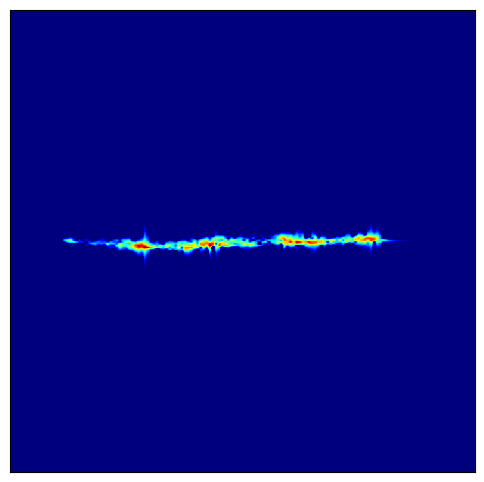

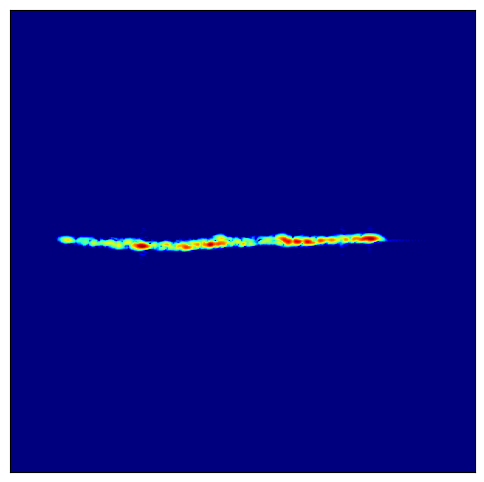

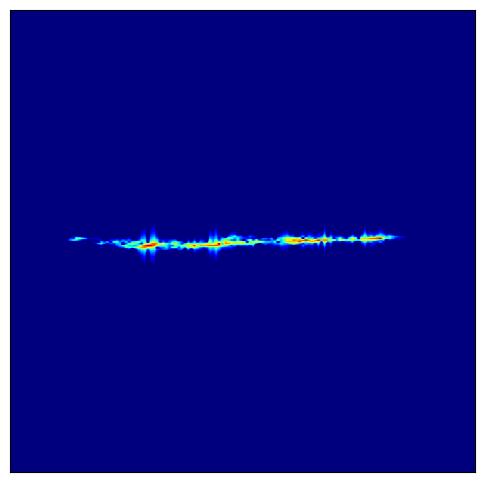

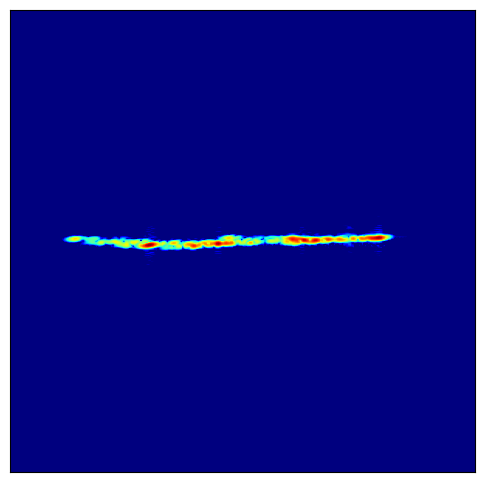

第59/200帧图像计算
转动方位起点25.98859747841832
转动方位终点26.31107390764629
转动方位总角度0.3224764292279687
转动俯仰起点85.16131959262749
转动俯仰终点85.10580095885048
转动俯仰总角度0.05551863377701238
网格数10602
RCS计算完毕
数据已保存为mat
最优: vel=0.4726, acc=-0.4893, entropy=3.6374


<Figure size 640x480 with 0 Axes>

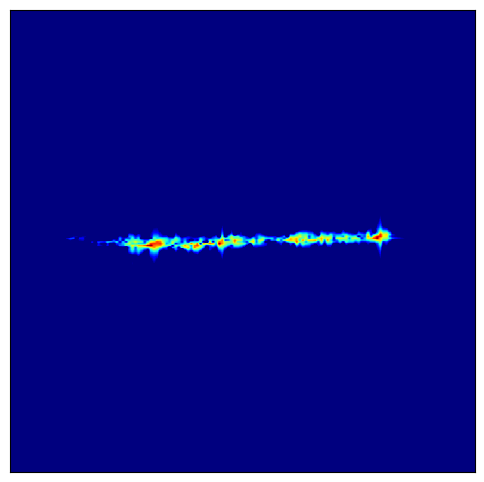

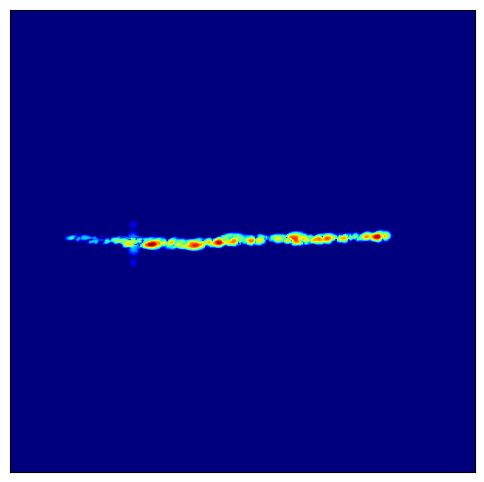

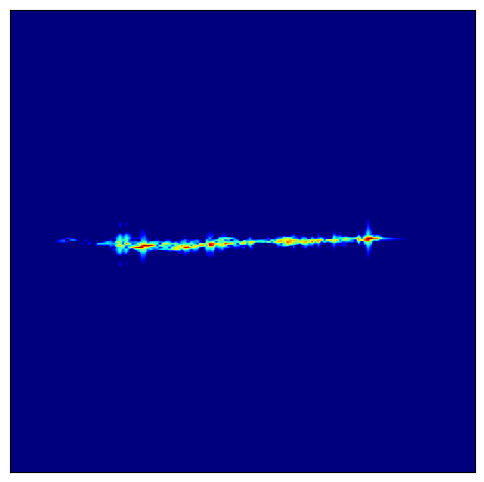

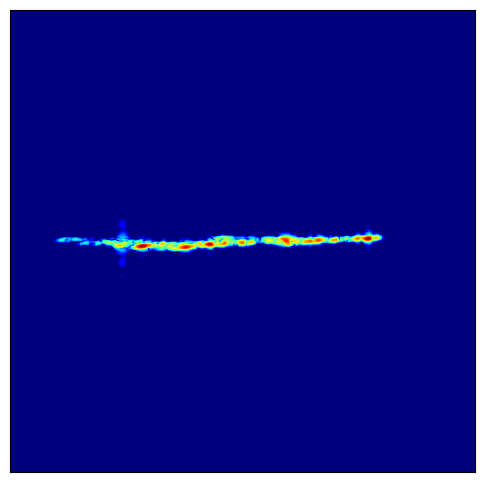

第61/200帧图像计算
转动方位起点26.64106238459918
转动方位终点26.97880581456242
转动方位总角度0.3377434299632398
转动俯仰起点85.04915826435351
转动俯仰终点84.99136366941171
转动俯仰总角度0.05779459494179662
网格数10602
RCS计算完毕
数据已保存为mat
最优: vel=0.0068, acc=0.0504, entropy=3.5439


<Figure size 640x480 with 0 Axes>

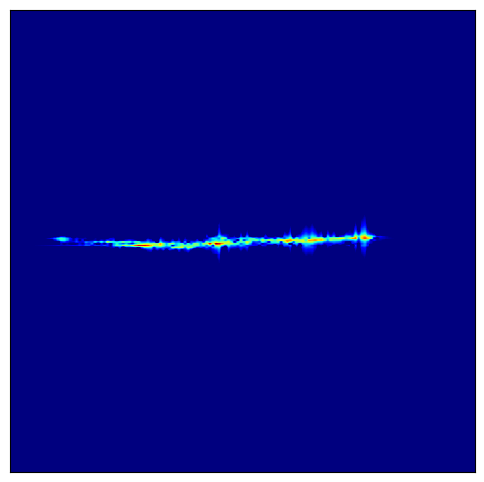

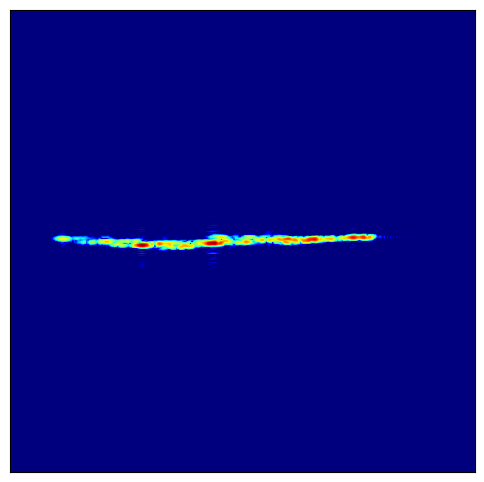

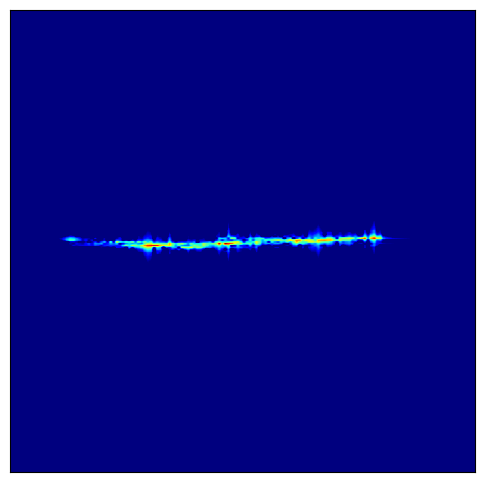

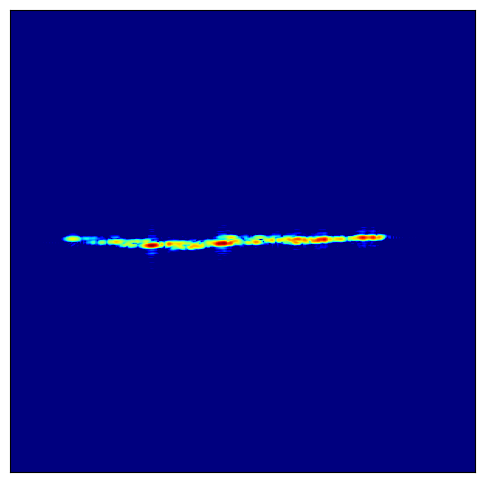

第63/200帧图像计算
转动方位起点27.324556497367485
转动方位终点27.678576504219706
转动方位总角度0.35402000685222035
转动俯仰起点84.93238880260698
转动俯仰终点84.87220478360946
转动俯仰总角度0.060184018997517796
网格数10602
RCS计算完毕
数据已保存为mat
最优: vel=0.3609, acc=-0.3505, entropy=3.5687


<Figure size 640x480 with 0 Axes>

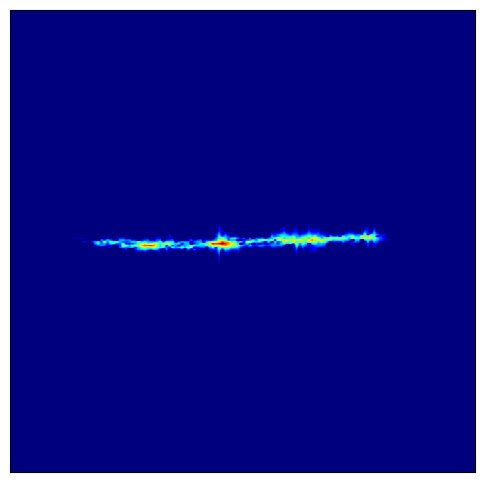

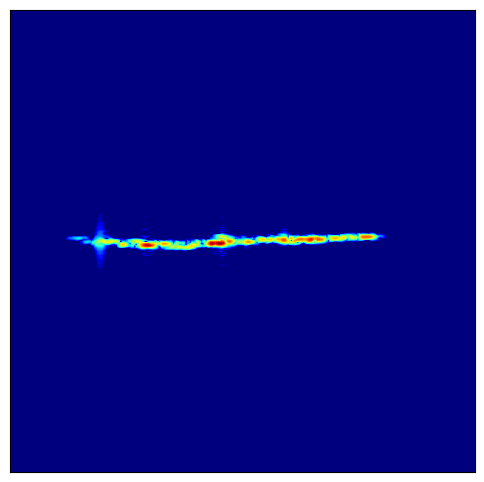

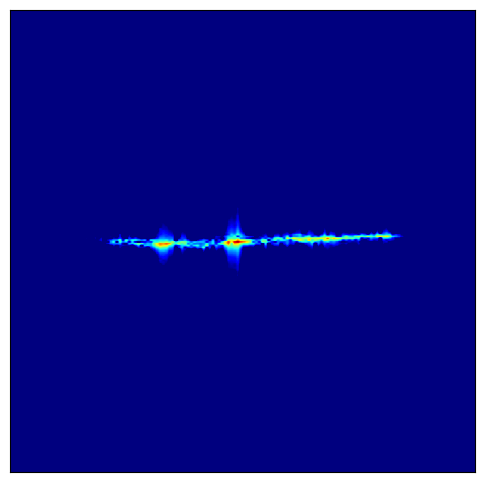

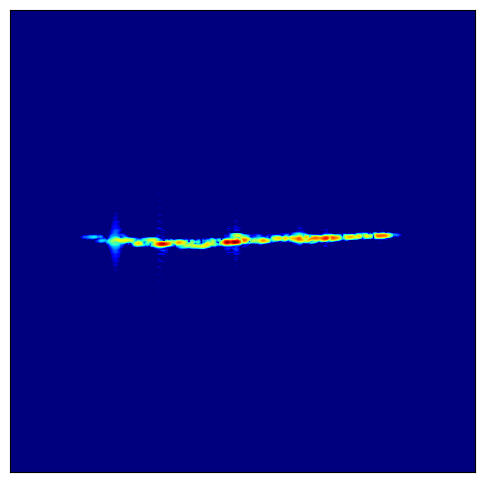

第65/200帧图像计算
转动方位起点28.041138065530017
转动方位终点28.41252396923294
转动方位总角度0.37138590370292235
转动俯仰起点84.8107822514099
转动俯仰终点84.74809139870777
转动俯仰总角度0.06269085270213282
网格数10602
RCS计算完毕
数据已保存为mat
最优: vel=0.4822, acc=-0.3134, entropy=3.5401


<Figure size 640x480 with 0 Axes>

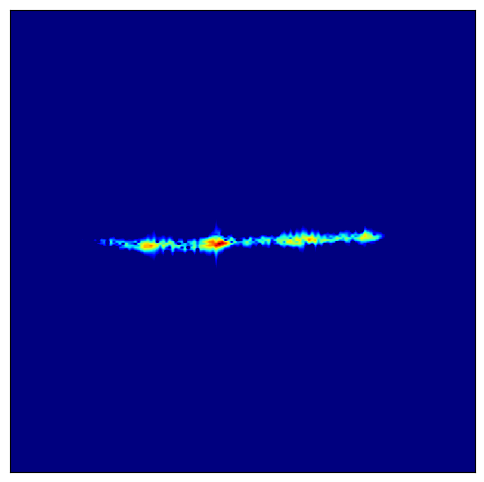

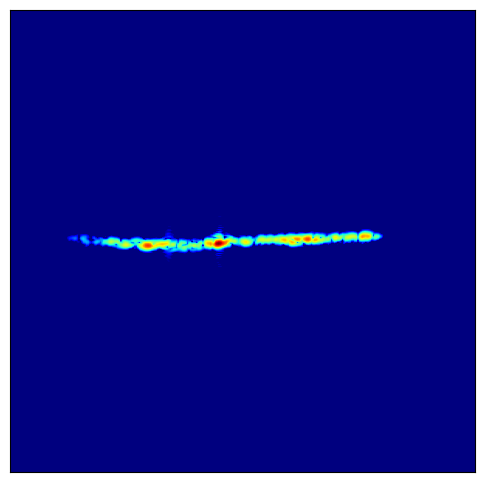

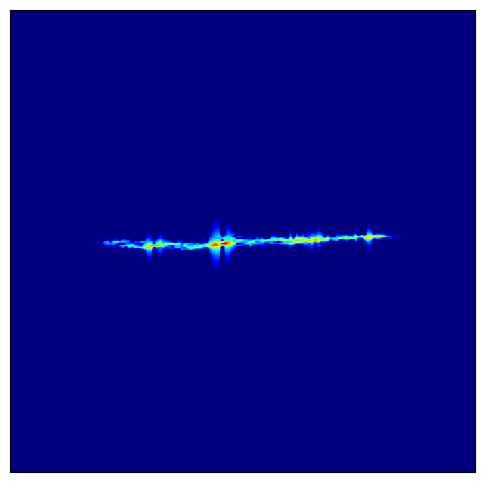

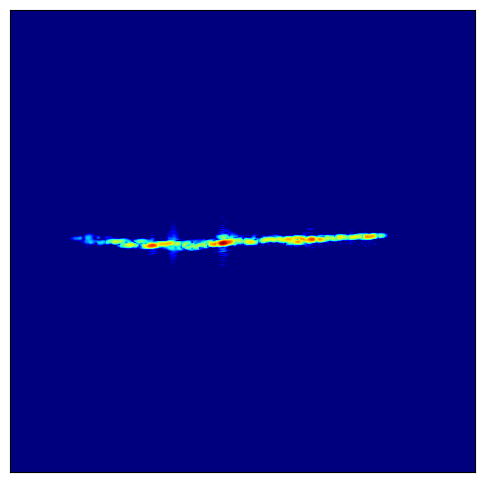

第67/200帧图像计算
转动方位起点28.793027968897263
转动方位终点29.18295520072709
转动方位总角度0.3899272318298266
转动俯仰起点84.68410201323846
转动俯仰终点84.61878352690727
转动俯仰总角度0.06531848633119353
网格数10602
RCS计算完毕
数据已保存为mat
最优: vel=0.3548, acc=-0.2754, entropy=3.6101


<Figure size 640x480 with 0 Axes>

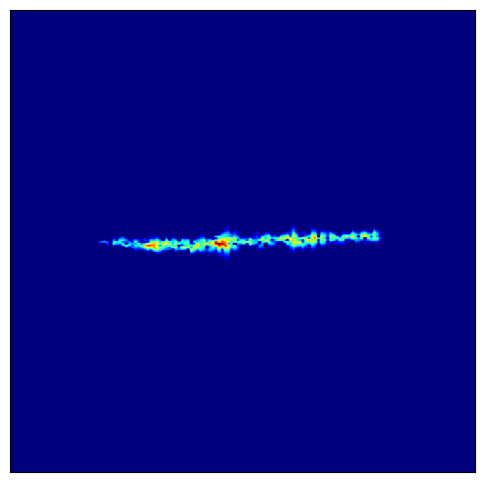

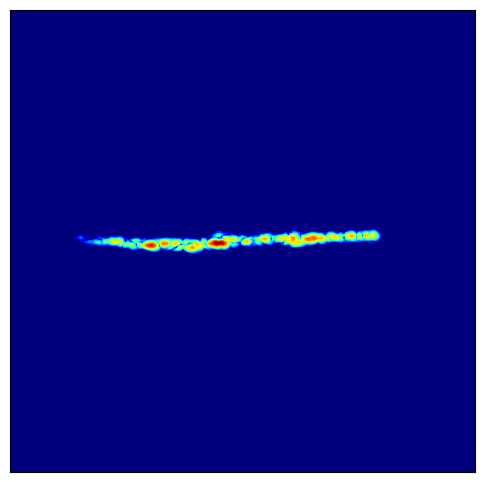

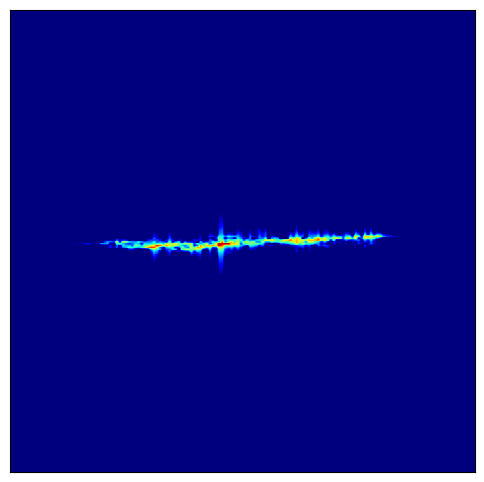

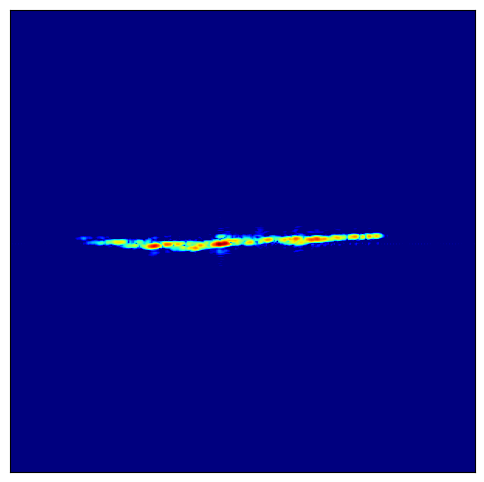

第69/200帧图像计算
转动方位起点29.582622608310896
转动方位终点29.992359373697095
转动方位总角度0.4097367653861994
转动俯仰起点84.5521050736923
转动俯仰终点84.48403555737904
转动俯仰总角度0.0680695163132583
网格数10602
RCS计算完毕
数据已保存为mat
最优: vel=2.0343, acc=-1.8945, entropy=3.6326


<Figure size 640x480 with 0 Axes>

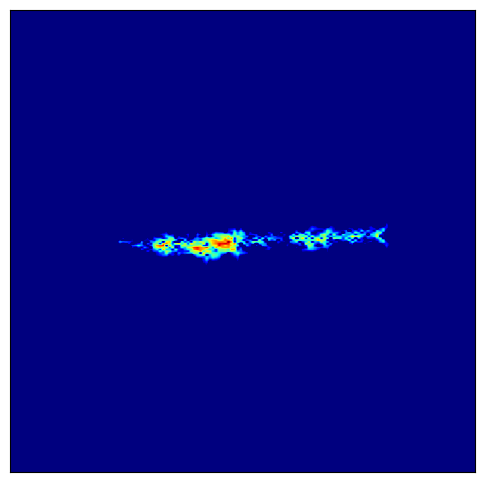

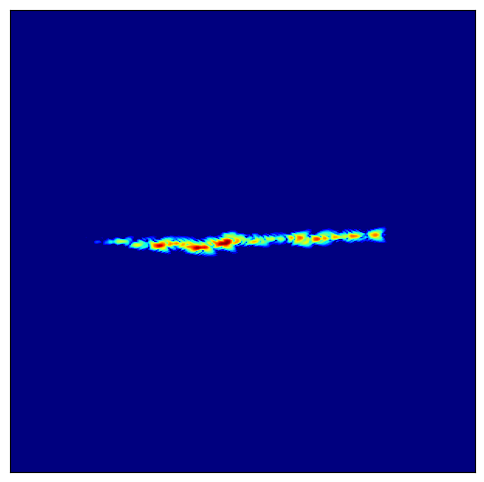

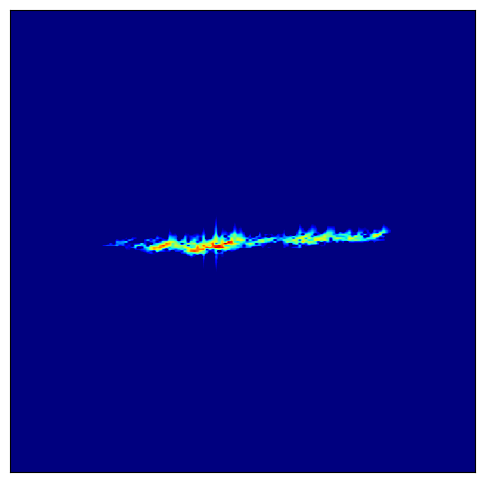

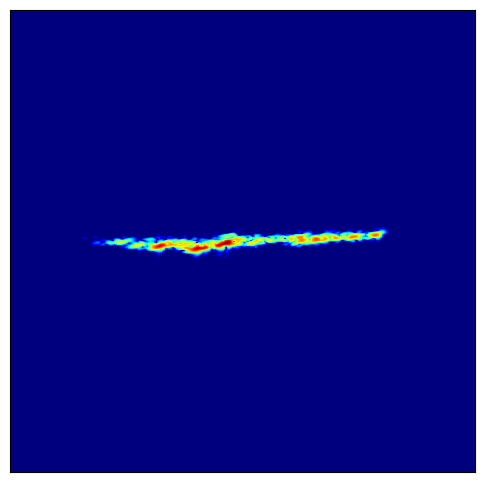

第71/200帧图像计算
转动方位起点30.412507353052895
转动方位终点30.843421514791796
转动方位总角度0.43091416173890096
转动俯仰起点84.41454373030032
转动俯仰终点84.34359828437485
转动俯仰总角度0.07094544592547436
网格数10602
RCS计算完毕
数据已保存为mat
最优: vel=7.0181, acc=-6.6434, entropy=3.8188


<Figure size 640x480 with 0 Axes>

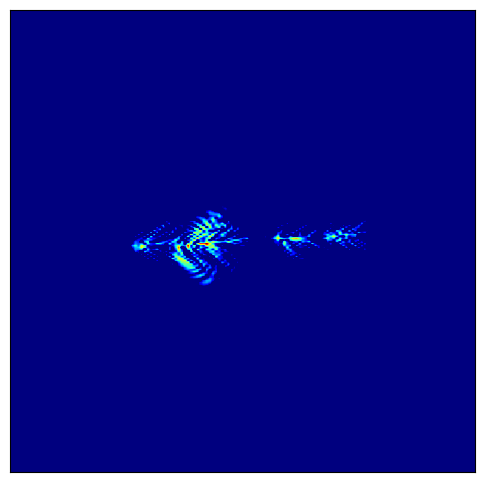

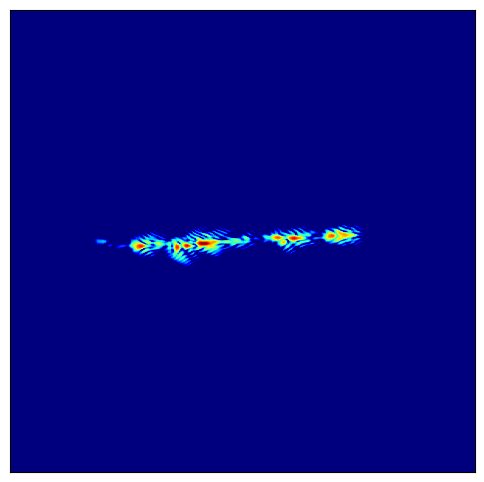

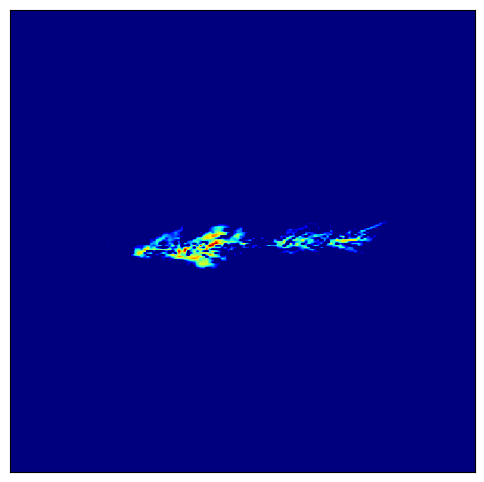

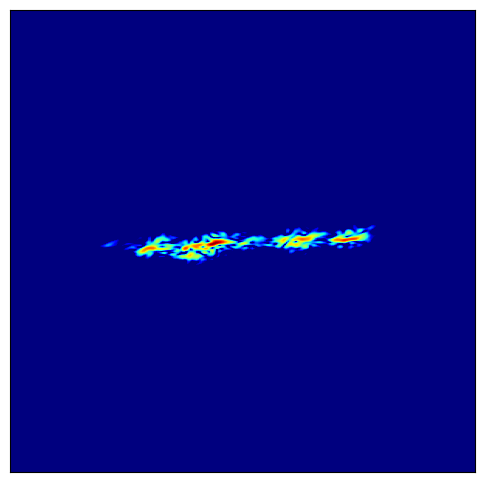

第73/200帧图像计算
转动方位起点31.285470377630908
转动方位终点31.739036445551083
转动方位总角度0.45356606792017473
转动俯仰起点84.27116795586598
转动俯仰终点84.19722164542127
转动俯仰总角度0.07394631044471112
网格数10602
RCS计算完毕
数据已保存为mat
最优: vel=-0.9222, acc=0.8822, entropy=3.5965


<Figure size 640x480 with 0 Axes>

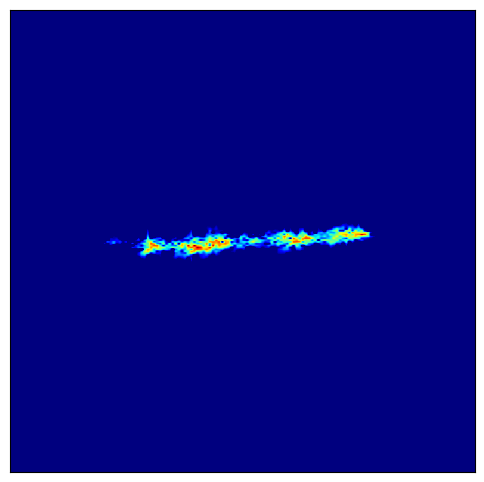

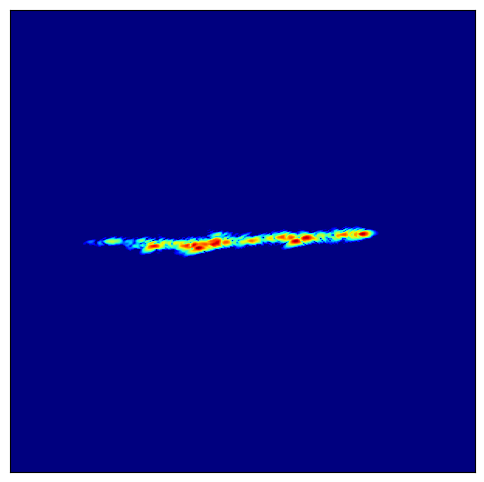

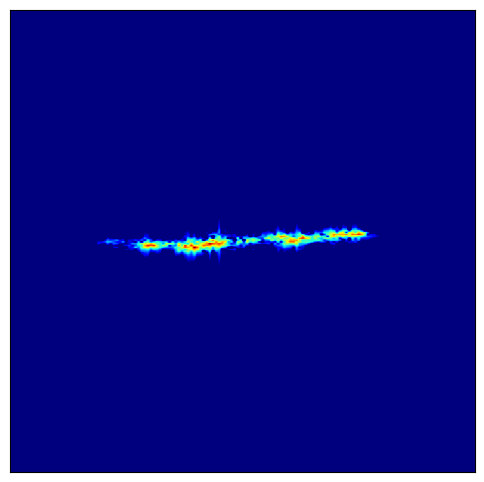

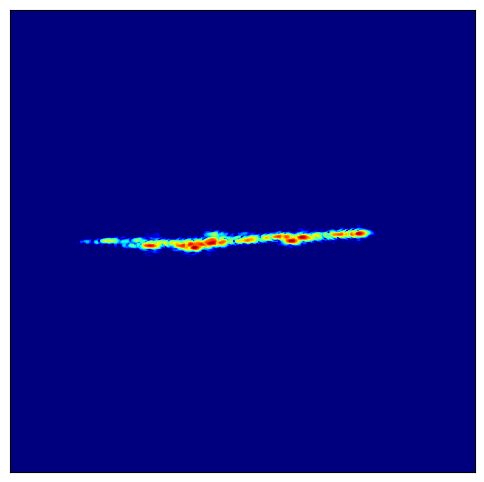

第75/200帧图像计算
转动方位起点32.204516636077955
转动方位终点32.68232269766887
转动方位总角度0.4778060615909183
转动俯仰起点84.12172855510023
转动俯仰终点84.04465834425483
转动俯仰总角度0.077070210845406
网格数10602


KeyboardInterrupt: 

In [39]:
距离向采样点数 = 频率点数量
方位向采样点数 = 每帧图像的脉冲串数量
isar_images = []  # 存储每一帧的幅度图或复数图
采样位置 = np.zeros((方位向采样点数, 3))
# for z in range(图像帧数):
for z in range(0, 图像帧数, 2):
    当前帧数=z+1
    print(f"第{当前帧数}/{图像帧数}帧图像计算")
    采样起点 = 路径点数组[当前帧数-1]
    采样终点 = 路径点数组[当前帧数]
    采样位置[:, 0] = np.linspace(采样起点[0], 采样终点[0], 方位向采样点数)
    采样位置[:, 1] = np.linspace(采样起点[1], 采样终点[1], 方位向采样点数)
    采样位置[:, 2] = np.linspace(采样起点[2], 采样终点[2], 方位向采样点数)

    # 计算雷达方位角、俯仰角
    方位角列表 = []
    俯仰角列表 = []
    滚转角 = 0
    俯仰角 = 0
    偏航角 = 目标航向角
    for i in range(方位向采样点数):
        目标位置 = np.array([[采样位置[i, :][0]], [采样位置[i, :][1]], [采样位置[i, :][2]]])
        当前雷达方位角, 当前雷达俯仰角 = 仿真角度(目标位置, 滚转角, 俯仰角, 偏航角)
        方位角列表.append(当前雷达方位角)
        俯仰角列表.append(当前雷达俯仰角)
    方位角矩阵 = np.array(方位角列表)
    俯仰角矩阵 = np.array(俯仰角列表)
    print(f'转动方位起点{方位角矩阵[0]}')
    print(f'转动方位终点{方位角矩阵[-1]}')
    print(f'转动方位总角度{np.max(方位角矩阵)-np.min(方位角矩阵)}')
    print(f'转动俯仰起点{俯仰角矩阵[0]}')
    print(f'转动俯仰终点{俯仰角矩阵[-1]}')
    print(f'转动俯仰总角度{np.max(俯仰角矩阵)-np.min(俯仰角矩阵)}')

    mesh = meshio.read('./Feiji.stl')
    vertices = mesh.points
    faces = mesh.cells_dict['triangle']
    目标网格 = Mesh([vertices, faces])
    print(f"网格数{len(faces)}")
    show(目标网格, axes=True, azimuth=30, elevation=0)

    频率点 = np.arange(起始频率, 起始频率 + 带宽, 频率步长)
    frequencies = 频率点/1e9
    最大反射次数 = 最大反射次数
    RCS_HH = np.zeros((方位向采样点数, 距离向采样点数), dtype=complex)
    RCSdB_HH = np.zeros((方位向采样点数, 距离向采样点数))
    RCS_VV = np.zeros((方位向采样点数, 距离向采样点数), dtype=complex)
    RCSdB_VV = np.zeros((方位向采样点数, 距离向采样点数))
    for i in range(方位向采样点数):
        zeniths = np.array([俯仰角矩阵[i]])
        azimuths = np.array([方位角矩阵[i]])
        生成器 = RCS计算1.generator(vertices, faces, frequencies, zeniths, azimuths, 1)
        for zenith下标, azimuth下标, zenith, azimuth, rcshh, rcsvv, rcs_po_hh各次反射贡献, rcs_po_vv各次反射贡献, rcs_ptd_hh, rcs_ptd_vv in 生成器:
            RCS_HH[i, :] = rcshh
            RCSdB_HH[i, :] = 20 * np.log10(np.abs(rcshh))
            RCS_VV[i, :] = rcsvv
            RCSdB_VV[i, :] = 20 * np.log10(np.abs(rcsvv))
    print(f"RCS计算完毕")

    回波矩阵 = np.zeros((方位向采样点数, 距离向采样点数), dtype=complex)
    for i in range(方位向采样点数):
        当前目标位置 = 采样位置[i]
        当前目标距离 = np.linalg.norm(当前目标位置 - 雷达位置)
        for k in range(距离向采样点数):
            # 回波信号 (已去除载频): exp(-j4πfR/c)
            回波矩阵[i, k] = np.exp(-1j * 4 * np.pi * 频率点[k] * 当前目标距离 / 光速)
    回波矩阵 = 回波矩阵 * RCS_VV
    save_dict = {
        'Rx': 回波矩阵,
        'f0': 起始频率,
        'Df': 频率步长,
        't0': 脉冲重复间隔,
    }
    savemat(f'./回波矩阵_速度={目标速度}_航向角={目标航向角}_高度={目标高度}_反射次数={最大反射次数}.mat', save_dict)
    print("数据已保存为mat")
    import matlab.engine

    # # 启动引擎（默认窗口不可见）
    eng = matlab.engine.start_matlab()
    eng.cd('D:\ISAR数据集(wwx)\连续多帧', nargout=0)

    filename = f'回波矩阵_速度={目标速度}_航向角={目标航向角}_高度={目标高度}_反射次数={最大反射次数}.mat'
    eng.eval(f"load('{filename}')", nargout=0)

    # 直接传递参数给 r_d 函数（参数必须是 MATLAB 类型，如 double）
    eng.r_d(float(目标速度), float(目标航向角), float(目标高度), int(最大反射次数), nargout=0)
    # eng.r_d(int(当前帧数), nargout=0)

    result_filename = f'Xf_速度={目标速度}_航向角={目标航向角}_高度={目标高度}_反射次数={最大反射次数}.mat'
    data = loadmat(result_filename)
    回波矩阵 = data['Xf'].T

    eng.quit()
    # 距离剖面
    距离像 = fft(回波矩阵, axis=1)
    距离像0 = 20 * np.log10(np.abs(距离像) + 1e-10)
    max_val = np.max(距离像0)
    G = 距离像
    Rx = 回波矩阵
    nb, ns = G.shape
    # 距离对齐后的ISAR成像
    # 熵处理进行距离对齐
    H_entropy = np.zeros((nb, ns))
    R_shifts = np.zeros(nb, dtype=int)

    for p in range(nb):
        for k in range(ns):
            x1 = np.abs(G[0, :])  # 参考信号（第1个脉冲的幅度）
            G_shift = np.roll(np.abs(G[p, :]), k)  # 当前脉冲循环移位
            x2 = np.abs(G_shift)
            x12 = x1 + x2  # 联合信号（参考 + 移位后）
            SUM_x12 = np.sum(x12)  # 归一化因子
            P = x12 / SUM_x12  # 概率分布（归一化联合信号）
            H_entropy[p, k] = -np.sum(P * np.log10(P + 1e-10))  # 熵计算
            # 熵公式为 H=−∑PlogP，其中 P是联合信号的归一化幅度。熵越小，表示信号对齐程度越好

        minvl, minind = np.min(H_entropy[p, :]), np.argmin(H_entropy[p, :])  # 最小熵值及其索引
        R_shifts[p] = minind
    # 解缠距离图
    Wr = 光速 / (2 * 频率步长)
    Y = R_shifts.copy()
    # 当相邻脉冲的距离偏移量变化超过半个距离单元时，进行补偿。(这部分没搞懂)
    for n in range(1, nb):
        # 如果当前距离偏移比前一个小超过半个距离单元，则加上一个距离单元
        if R_shifts[n] < R_shifts[n - 1] - ns / 2:
            R_shifts[n:] = R_shifts[n:] + ns
        # 如果当前距离偏移比前一个大超过半个距离单元，则减去一个距离单元
        if R_shifts[n] > R_shifts[n - 1] + ns / 2:
            R_shifts[n:] = R_shifts[n:] - ns
    TIME = (np.arange(nb) * 脉冲重复间隔 * ns).T
    RANGErc = (R_shifts * (Wr / ns)).T

    # 线性拟合（匀速运动模型）
    coefficients1 = np.polyfit(TIME, RANGErc, deg=1)  # 返回 [a, b]，对应 y = ax + b
    A, B = coefficients1[1], coefficients1[0]
    # 二次拟合（匀加速运动模型）
    coefficients2 = np.polyfit(TIME, RANGErc, deg=2)  # 返回 [a, b, c]，对应 y = ax² + bx + c
    C, D, E = coefficients2[2], coefficients2[1], coefficients2[0]
    # 计算多项式在给定点的值
    R1 = np.polyval(coefficients1, TIME)  # 线性拟合结果
    R2 = np.polyval(coefficients2, TIME)  # 二次拟合结果

    E1 = np.sqrt(np.sum((RANGErc - R1) ** 2))  # 线性误差
    E2 = np.sqrt(np.sum((RANGErc - R2) ** 2))  # 二次误差

    if E2 <= E1 / 1.2:
        re, ve, ae = C, D, E
    else:
        re, ve, ae = A, B, 0

    # 将外推延迟转换为实际延迟
    fe = 中心频率 + (ns / 2) * 频率步长  # 终止频率
    s = 频率步长 / 脉冲重复间隔
    cc = fe / s
    ar = ae
    vr = ve - cc * ar
    rr = re - cc * vr
    CRG = rr + vr * TIME + 0.5 * ar * (TIME ** 2)
    # 估计运动学
    imn = np.arange(ns * nb) + 1  # 脉冲索引
    tmn = imn * 脉冲重复间隔  # 时间轴
    fmn = 中心频率 + 频率步长 * np.remainder(imn - 1, ns)  # 频率轴
    PSI = np.rot90(Rx, 1)  # 逆时针旋转 90 度
    rr = rr + Wr / 2  # 添加半距离窗
    Rrc = rr + vr * tmn + (1 / 2) * ar * (tmn ** 2)  # 考虑运动补偿的距离
    # 生成滤波器
    vector = np.ravel(PSI, order='F')  # 按列优先展开
    filter = vector * np.exp((-1j * 4 * np.pi / 光速) * (fmn * Rrc))
    # 填充到矩阵（列优先）
    RCP_PSI = filter.reshape(ns, nb, order='F')
    G_aligned = fft(RCP_PSI, axis=0)  #对每一列（沿行方向）进行 FFT,对距离向进行FFT
    RG = np.rot90(G_aligned, k=3)  # 逆时针旋转270度
    # RG = np.fliplr(np.flipud(np.rot90(G)))  #旋转 90 度（逆时针）,上下翻转（flipud）,左右翻转（fliplr）。
    # 将目标居中
    [rm, rn] = RG.shape
    nmax = np.argmax(np.max(np.abs(RG), axis=0))  #沿行方向（求得最大值索引列）
    nsplit = (nmax + rn // 2) % rn
    if nsplit == 0:
        nsplit = rn
    RG = np.hstack([RG[:, nsplit:rn], RG[:, :nsplit]])

    plt.figure()
    fft_image_aligned = 20 * np.log10(np.abs(RG) + 1e-10)
    max_val = np.max(fft_image_aligned)
    # 相位补偿-熵最小化后的ISAR成像
    # 熵最小化进行相位补偿
    f = 起始频率 + np.arange(ns) * 频率步长
    T = tmn.reshape(ns, nb, order='F')
    F = f.reshape(-1, 1) * np.ones((1, nb))


    # 用闭包把原始数据包进去，避免误改
    def make_objective(F, T, RCP_PSI, 光速):
        def objective(params):
            vel, acc = params
            S = np.exp((1j * 4 * np.pi * F / 光速) * (vel * T + 0.5 * acc * T ** 2))
            S1 = RCP_PSI * S
            Sft = np.abs(np.fft.fftshift(np.fft.fft2(S1)))
            SumS = np.sum(Sft)
            I = Sft / (SumS + 1e-10)
            entropy = -np.sum(I * np.log10(I + 1e-10))
            return entropy

        return objective


    # 使用你已有的原始变量
    obj = make_objective(F, T, RCP_PSI, 光速)

    # 定义搜索空间
    space = [Real(-20, 20, name='vel'),
             Real(-10, 10, name='acc')]

    # 贝叶斯优化（只会改 vel, acc，不会动其他任何变量）
    result = gp_minimize(obj, space, n_calls=100, random_state=42)
    optimal_vel, optimal_acc = result.x
    print(f'最优: vel={optimal_vel:.4f}, acc={optimal_acc:.4f}, entropy={result.fun:.4f}')
    PHcorr = (optimal_vel * T + (0.5 * optimal_acc * (T ** 2)))
    Scorr = np.exp((1j * 4 * np.pi * F / 光速) * PHcorr)
    # 校正相位函数
    PHC_PSI = RCP_PSI * Scorr
    # 生成ISAR图像
    TMP1 = np.rot90(fft(PHC_PSI, axis=0), -1)
    [rm, rn] = TMP1.shape
    nmax = np.argmax(np.max(np.abs(TMP1), axis=0))
    nsplit = (nmax + rn // 2) % rn
    if nsplit == 0:
        nsplit = rn
    TMP = np.hstack([TMP1[:, nsplit:rn], TMP1[:, :nsplit]])
    IMG = fft(TMP, axis=0)
    # IMG_centered = center_target_robust(IMG, threshold_factor=0.3, min_area=30)
    # IMG_centered = center_target_balanced(IMG, threshold_factor=0.3, min_area=30)
    # IMG_centered = center_target_robust(IMG_centered, threshold_factor=0.3, min_area=30)
    IMG_centered = center_target_robust(IMG, threshold_factor=0.3, min_area=30)
    IMG_centered = center_by_projection(IMG_centered)
    IMG_centered = center_by_projection(IMG_centered)
    save_dir = f'./Feiji/Feiji图像数据/速度={目标速度}_航向角={目标航向角}_高度={目标高度}_反射次数={最大反射次数}'
    os.makedirs(save_dir, exist_ok=True)
    mat_path = os.path.join(save_dir,
                            f'IMG_centered_第{当前帧数}帧.mat')
    savemat(mat_path, {'IMG_centered': IMG_centered})

    # 后续显示和保存改用 IMG_centered
    plt.figure(figsize=(6, 6))
    # max_val = np.max(20 * np.log10(np.abs(IMG_centered) + 1e-10))
    dB_image = 20 * np.log10(np.abs(IMG_centered) + 1e-10)
    vmin, vmax = auto_display_range(dB_image, method='percentile', percentile=98)
    plt.imshow(
        20 * np.log10(np.abs(IMG_centered)),
        extent=[-距离范围 / 2, 距离范围 / 2, -多普勒频率跨度 / 2, 多普勒频率跨度 / 2],
        aspect='auto',
        cmap='jet',
        vmin=vmin,
        vmax=vmax
    )
    plt.rc('axes', grid=False)
    plt.xticks([])
    plt.yticks([])
    save_path = f'./Feiji/Feiji数据集/速度={目标速度}_航向角={目标航向角}_高度={目标高度}_反射次数={最大反射次数}/第{当前帧数}帧_1.png'
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path)
    plt.show()
    # 加窗和补零
    运动补偿后的原始数据 = ifft2(IMG_centered)
    方位向采样点数 = 运动补偿后的原始数据.shape[0]
    距离向采样点数 = 运动补偿后的原始数据.shape[1]
    方位向窗 = np.hamming(方位向采样点数)
    距离向窗 = np.hamming(距离向采样点数)
    二维窗 = np.outer(方位向窗, 距离向窗)
    加窗后数据 = 运动补偿后的原始数据 * 二维窗
    补零后数据 = np.zeros((2 * 方位向采样点数, 2 * 距离向采样点数), dtype=np.complex128)
    补零后数据[:方位向采样点数, :距离向采样点数] = 加窗后数据
    补零后数据[补零后数据 == 0] = np.min(np.abs(加窗后数据))

    ISAR_fft = fft2(补零后数据)
    # max_val = np.max(20 * np.log10(np.abs(ISAR_fft)))
    dB_image = 20 * np.log10(np.abs(ISAR_fft) + 1e-10)
    vmin, vmax = auto_display_range(dB_image, method='percentile', percentile=98)
    plt.figure(figsize=(6, 6))
    plt.imshow(
        20 * np.log10(np.abs(ISAR_fft)),
        extent=[-距离范围 / 2, 距离范围 / 2, -多普勒频率跨度 / 2, 多普勒频率跨度 / 2],
        aspect='auto',
        cmap='jet',
        vmin=vmin,
        vmax=vmax
    )
    plt.rc('axes', grid=False)
    plt.xticks([])  # 隐藏横坐标数字
    plt.yticks([])  # 隐藏纵坐标数字
    save_path = f'./Feiji/Feiji数据集/速度={目标速度}_航向角={目标航向角}_高度={目标高度}_反射次数={最大反射次数}/第{当前帧数}帧_2.png'
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path)
    plt.show()

    RG1, phi, ref = phase_adjustment(RG, 3)
    # 相位补偿后的ISAR 成像
    # 对 RG1 沿脉冲方向（行）做 FFT，并中心化（fftshift）
    G1 = fft(RG1, axis=0)
    # G1_centered = center_target_robust(G1, threshold_factor=0.3, min_area=30)
    # G1_centered = center_target_balanced(G1, threshold_factor=0.3, min_area=30)
    # G1_centered = center_target_robust(G1_centered, threshold_factor=0.3, min_area=30)
    G1_centered = center_target_robust(G1, threshold_factor=0.3, min_area=30)
    G1_centered = center_by_projection(G1_centered)
    G1_centered = center_by_projection(G1_centered)

    save_dir = f'./Feiji/Feiji图像数据/速度={目标速度}_航向角={目标航向角}_高度={目标高度}_反射次数={最大反射次数}'
    os.makedirs(save_dir, exist_ok=True)
    mat_path = os.path.join(save_dir,
                            f'G1_centered_第{当前帧数}帧.mat')
    savemat(mat_path, {'G1_centered': G1_centered})

    # max_val = np.max(20 * np.log10(np.abs(G1_centered)))
    dB_image = 20 * np.log10(np.abs(G1_centered) + 1e-10)
    vmin, vmax = auto_display_range(dB_image, method='percentile', percentile=98)
    plt.figure(figsize=(6, 6))
    plt.imshow(
        20 * np.log10(np.abs(G1_centered)),
        extent=[-距离范围 / 2, 距离范围 / 2, -多普勒频率跨度 / 2, 多普勒频率跨度 / 2],
        aspect='auto',
        cmap='jet',
        vmin=vmin,
        vmax=vmax
    )
    plt.rc('axes', grid=False)
    plt.xticks([])  # 隐藏横坐标数字
    plt.yticks([])  # 隐藏纵坐标数字
    save_path = f'./Feiji/Feiji数据集/速度={目标速度}_航向角={目标航向角}_高度={目标高度}_反射次数={最大反射次数}/第{当前帧数}帧_3.png'
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path)
    plt.show()

    # 加窗和补零
    运动补偿后的原始数据 = ifft2(G1_centered)
    方位向采样点数 = 运动补偿后的原始数据.shape[0]
    距离向采样点数 = 运动补偿后的原始数据.shape[1]
    方位向窗 = np.hamming(方位向采样点数)
    距离向窗 = np.hamming(距离向采样点数)
    二维窗 = np.outer(方位向窗, 距离向窗)
    加窗后数据 = 运动补偿后的原始数据 * 二维窗
    补零后数据 = np.zeros((2 * 方位向采样点数, 2 * 距离向采样点数), dtype=np.complex128)
    补零后数据[:方位向采样点数, :距离向采样点数] = 加窗后数据
    补零后数据[补零后数据 == 0] = np.min(np.abs(加窗后数据))

    ISAR_fft = fft2(补零后数据)
    # max_val = np.max(20 * np.log10(np.abs(ISAR_fft)))
    dB_image = 20 * np.log10(np.abs(ISAR_fft) + 1e-10)
    vmin, vmax = auto_display_range(dB_image, method='percentile', percentile=98)
    # 7. 显示图像
    plt.figure(figsize=(6, 6))
    plt.imshow(
        20 * np.log10(np.abs(ISAR_fft)),
        extent=[-距离范围 / 2, 距离范围 / 2, -多普勒频率跨度 / 2, 多普勒频率跨度 / 2],
        aspect='auto',
        cmap='jet',
        vmin=vmin,
        vmax=vmax
    )

    plt.rc('axes', grid=False)
    plt.xticks([])  # 隐藏横坐标数字
    plt.yticks([])  # 隐藏纵坐标数字
    save_path = f'./Feiji/Feiji数据集/速度={目标速度}_航向角={目标航向角}_高度={目标高度}_反射次数={最大反射次数}/第{当前帧数}帧_4.png'
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path)
    plt.show()
